 
<h1>Tarification du coût des sinistres auto : attritionnels vs atypiques</h1>

Notebook complet de modélisation hors GLM

<p>Membres du groupe :</p>
<ul>
    <li><strong>DIOUF </strong> Salimata</li>
    <li><strong>KOUAME </strong> CHRIST ANGE DYLAN</li>
    <li><strong>OUATTARA </strong> ABOUBAKAR</li>
    <li><strong>OUATTARA </strong> SOULEYMANE</li>
</ul>


Ce notebook construit une **composante coût / sévérité** exploitable pour le tarif final, en séparant :

- les **sinistres attritionnels** ;
- les **sinistres atypiques**.

L'objectif n'est **pas** de modéliser la fréquence ici.  
La sortie finale de ce notebook est donc une **prime de coût par sinistre** (ou **sévérité attendue par sinistre**) :

---

## Pourquoi cette approche ?

Une seule modélisation de la sévérité sur tous les sinistres est souvent pénalisée par :
- la très forte asymétrie des montants ;
- la présence d'une queue lourde ;
- la petite population des gros sinistres.

D'où la stratégie en 3 briques :

1. **Modéliser les attritionnels** avec des méthodes ML / GAM-like adaptées à une cible positive et asymétrique ;
2. **Modéliser les atypiques** avec une logique EVT (théorie des valeurs extrêmes) et un benchmark ML ;
3. **Recombiner** les deux avec un modèle de probabilité d'être atypique.

---

## Sorties attendues

Le notebook produit :
- des analyses descriptives complètes ;
- des tests de lois ;
- des modèles attritionnels ;
- des modèles atypiques ;
- un score de probabilité atypique ;
- une **prime de coût par sinistre** ;
- des graphiques de cohérence tarifaire ;
- des fichiers exportables pour la suite du projet.

**Note** : Attention, la base de données chargée intialement provient des traitements dans la partie sur la modelisaiton par GLM et la frequence par Machine learning ( base stockée en local , risque d'erreur si réexecution du notebook)

**Note** : Prière de changer le **repertoire DATA_DIR au niveau du chargement des données** et de renseigné celui où sont stockées les bases ( "freMTPLfreq.csv" et "basecout.csv") obtenues dans le script R (modelisation GLM)

In [82]:
!pip install xgboost lightgbm

In [83]:

# 0.Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import genpareto, gamma, lognorm, weibull_min
from scipy.special import boxcox1p

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    roc_auc_score,
    log_loss,
    brier_score_loss
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

In [84]:

# 1.Chargement des données

DATA_DIR = Path(r"C:\Users\dylan\Desktop\GGvie\exports_segmentation")

ATTR_PATH = DATA_DIR / "cout_attritionnel_prepare.csv"
ATYP_PATH = DATA_DIR / "cout_atypique_prepare.csv"

attr = pd.read_csv(ATTR_PATH)
atyp = pd.read_csv(ATYP_PATH)

print("Shape attritionnel :", attr.shape)
print("Shape atypique     :", atyp.shape)
display(attr.head())
display(atyp.head())


Shape attritionnel : (15358, 22)
Shape atypique     : (461, 22)


,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,Region_cls,Brand_cls,Power_cls,CarAge_cls,log_Density,Density_cls,DriverAge_cls,has_claim,freq_obs,severity_per_claim,cost_per_exposure
0,33,302,1,0.75,g,1,61,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000,IDF,Asia,f-g-h,Véhicule récent [0-5],10.203592,Zone très dense >8,Conducteurs seniors ]60-80],1,1.333333,302.0,402.666667
1,41,2001,1,0.14,l,5,50,Japanese (except Nissan) or Korean,Diesel,Basse-Normandie,56,PDL-BN-HN-LIM,Asia,i-j-k-l+,Véhicule récent [0-5],4.025352,Zone densité modérée ]4-5],Conducteurs mûrs ]40-50],1,7.142857,2001.0,14292.857143
2,92,1449,1,0.14,d,0,36,Japanese (except Nissan) or Korean,Regular,Ile-de-France,4792,IDF,Asia,d-e,Véhicule récent [0-5],8.474703,Zone très dense >8,Conducteurs expérimentés ]30-40],1,7.142857,1449.0,10350.000000
3,96,946,2,0.62,j,0,51,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000,IDF,Asia,i-j-k-l+,Véhicule récent [0-5],10.203592,Zone très dense >8,Conducteurs seniors actifs ]50-60],1,3.225806,473.0,1525.806452
4,142,1390,1,0.75,e,0,34,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,1565,PC-NPDC-AQUIT,Asia,d-e,Véhicule récent [0-5],7.355641,Zone dense ]6-8],Conducteurs expérimentés ]30-40],1,1.333333,1390.0,1853.333333


,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,Region_cls,Brand_cls,Power_cls,CarAge_cls,log_Density,Density_cls,DriverAge_cls,has_claim,freq_obs,severity_per_claim,cost_per_exposure
0,96,9924,2,0.62,j,0,51,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000,IDF,Asia,i-j-k-l+,Véhicule récent [0-5],10.203592,Zone très dense >8,Conducteurs seniors actifs ]50-60],1,3.225806,4962.0,16006.451613
1,580,6518,1,0.15,g,2,71,Japanese (except Nissan) or Korean,Regular,Ile-de-France,2201,IDF,Asia,f-g-h,Véhicule récent [0-5],7.696667,Zone dense ]6-8],Conducteurs seniors ]60-80],1,6.666667,6518.0,43453.333333
2,643,8461,2,0.57,l,9,53,Japanese (except Nissan) or Korean,Regular,Ile-de-France,3110,IDF,Asia,i-j-k-l+,Véhicule intermédiaire ]5-10],8.042378,Zone très dense >8,Conducteurs seniors actifs ]50-60],1,3.508772,4230.5,14843.859649
3,1188,31889,2,0.42,k,0,45,Japanese (except Nissan) or Korean,Diesel,Ile-de-France,1248,IDF,Asia,i-j-k-l+,Véhicule récent [0-5],7.129298,Zone dense ]6-8],Conducteurs mûrs ]40-50],1,4.761905,15944.5,75926.190476
4,2812,69024,1,0.49,f,5,50,"Renault, Nissan or Citroen",Diesel,Bretagne,48,C-B,French_core,f-g-h,Véhicule récent [0-5],3.871201,Zone peu dense ]1-4],Conducteurs mûrs ]40-50],1,2.040816,69024.0,140865.306122



## 1.1 Audit rapide de structure

On vérifie :
- les dimensions ;
- les types ;
- les colonnes disponibles ;
- les montants ;
- les éventuelles modalités non renseignées.

**Remarque importante** : comme le notebook sert au tarif, on évite toute variable de fuite d'information comme :
- `severity_per_claim`
- `cost_per_exposure`
- `has_claim`
- `freq_obs`
- `PolicyID`

Ces variables pourront être conservées pour le contrôle, mais pas pour la prédiction finale.


In [85]:

# Audit structurel
def audit_df(df, name):
    print(f"\n===== Audit : {name} =====")
    print(df.dtypes)
    print("\nNA :")
    display(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nClaimAmount describe :")
    display(df["ClaimAmount"].describe([0.5, 0.9, 0.95, 0.99]))

audit_df(attr, "attritionnel")
audit_df(atyp, "atypique")



===== Audit : attritionnel =====
PolicyID                int64
ClaimAmount             int64
ClaimNb                 int64
Exposure              float64
Power                  object
CarAge                  int64
DriverAge               int64
Brand                  object
Gas                    object
Region                 object
Density                 int64
Region_cls             object
Brand_cls              object
Power_cls              object
CarAge_cls             object
log_Density           float64
Density_cls            object
DriverAge_cls          object
has_claim               int64
freq_obs              float64
severity_per_claim    float64
cost_per_exposure     float64
dtype: object

NA :


Density_cls           1
PolicyID              0
ClaimAmount           0
severity_per_claim    0
freq_obs              0
has_claim             0
DriverAge_cls         0
log_Density           0
CarAge_cls            0
Power_cls             0
Brand_cls             0
Region_cls            0
Density               0
Region                0
Gas                   0
Brand                 0
DriverAge             0
CarAge                0
Power                 0
Exposure              0
dtype: int64


ClaimAmount describe :


count    15358.000000
mean      1198.246647
std        934.125625
min          2.000000
50%       1151.000000
90%       2157.000000
95%       3137.150000
99%       5180.290000
max       6496.000000
Name: ClaimAmount, dtype: float64


===== Audit : atypique =====
PolicyID                int64
ClaimAmount             int64
ClaimNb                 int64
Exposure              float64
Power                  object
CarAge                  int64
DriverAge               int64
Brand                  object
Gas                    object
Region                 object
Density                 int64
Region_cls             object
Brand_cls              object
Power_cls              object
CarAge_cls             object
log_Density           float64
Density_cls            object
DriverAge_cls          object
has_claim               int64
freq_obs              float64
severity_per_claim    float64
cost_per_exposure     float64
dtype: object

NA :


PolicyID              0
ClaimAmount           0
severity_per_claim    0
freq_obs              0
has_claim             0
DriverAge_cls         0
Density_cls           0
log_Density           0
CarAge_cls            0
Power_cls             0
Brand_cls             0
Region_cls            0
Density               0
Region                0
Gas                   0
Brand                 0
DriverAge             0
CarAge                0
Power                 0
Exposure              0
dtype: int64


ClaimAmount describe :


count    4.610000e+02
mean     3.331903e+04
std      1.204014e+05
min      6.518000e+03
50%      1.117500e+04
90%      6.412500e+04
95%      9.690600e+04
99%      2.655276e+05
max      2.036833e+06
Name: ClaimAmount, dtype: float64

In [86]:

# 2. Nettoyage des modalités non renseignées

# On supprime toutes les lignes où une modalité qualitative est vide / non marquée.
# Cela évite de créer une pseudo-modalité artificielle et facilite l'interprétation.

CAT_COLS = [
    "Power", "Brand", "Gas", "Region",
    "Region_cls", "Brand_cls", "Power_cls",
    "CarAge_cls", "Density_cls", "DriverAge_cls"
]

BAD_TOKENS = {
    "", " ", "nan", "none", "null", "missing", "unknown",
    "na", "n/a", "non renseigné", "non_renseigne", "non renseignée",
    "not marked", "not_marked", "aucun", "?"
}

def remove_bad_modalities(df, cat_cols):
    clean = df.copy()
    for col in cat_cols:
        clean[col] = clean[col].astype(str).str.strip()
        clean = clean.loc[~clean[col].str.lower().isin(BAD_TOKENS)].copy()
    return clean

attr = remove_bad_modalities(attr, CAT_COLS)
atyp = remove_bad_modalities(atyp, CAT_COLS)

print("Shape attritionnel après nettoyage :", attr.shape)
print("Shape atypique après nettoyage     :", atyp.shape)


Shape attritionnel après nettoyage : (15357, 22)
Shape atypique après nettoyage     : (461, 22)


In [87]:

# Vérification finale
for name, df in [("attr", attr), ("atyp", atyp)]:
    print(f"\n{name}")
    bad_report = {}
    for col in CAT_COLS:
        vals = set(df[col].astype(str).str.strip().str.lower().unique())
        inter = vals.intersection(BAD_TOKENS)
        if inter:
            bad_report[col] = inter
    print("Modalités problématiques restantes :", bad_report if bad_report else "aucune")



attr
Modalités problématiques restantes : aucune

atyp
Modalités problématiques restantes : aucune



## 1.2 Colonnes retenues pour la modélisation

On se limite aux variables explicatives disponibles **au moment de la tarification** :

- `Power`, `Brand`, `Gas`, `Region`
- `Region_cls`, `Brand_cls`, `Power_cls`, `CarAge_cls`, `Density_cls`, `DriverAge_cls`
- `Exposure`, `CarAge`, `DriverAge`, `Density`, `log_Density`

On évite :
- `ClaimNb` : information proche de la fréquence, pas toujours connue à la souscription ;
- `severity_per_claim`, `cost_per_exposure` : variables dérivées du coût ;
- `has_claim`, `freq_obs`, `PolicyID` : non tarifaires ou fuites.

Nous allons cependant **tester aussi des variables croisées**:
- `DriverAge_cls × Density_cls`
- `Power_cls × Brand_cls`
- `Region_cls × Gas`


In [88]:

# 3. Feature engineering tarifaire

def add_interactions(df):
    out = df.copy()
    out["DriverAge_x_Density"] = out["DriverAge_cls"].astype(str) + " | " + out["Density_cls"].astype(str)
    out["Power_x_Brand"] = out["Power_cls"].astype(str) + " | " + out["Brand_cls"].astype(str)
    out["Region_x_Gas"] = out["Region_cls"].astype(str) + " | " + out["Gas"].astype(str)
    return out

attr = add_interactions(attr)
atyp = add_interactions(atyp)

BASE_CAT = [
    "Power", "Brand", "Gas", "Region",
    "Region_cls", "Brand_cls", "Power_cls",
    "CarAge_cls", "Density_cls", "DriverAge_cls"
]
INTER_CAT = ["DriverAge_x_Density", "Power_x_Brand", "Region_x_Gas"]
NUM_COLS = ["Exposure", "CarAge", "DriverAge", "Density", "log_Density"]

FEATURES_BASE = BASE_CAT + NUM_COLS
FEATURES_INT = BASE_CAT + INTER_CAT + NUM_COLS

print("Variables de base :", FEATURES_BASE)
print("Variables enrichies :", FEATURES_INT)


Variables de base : ['Power', 'Brand', 'Gas', 'Region', 'Region_cls', 'Brand_cls', 'Power_cls', 'CarAge_cls', 'Density_cls', 'DriverAge_cls', 'Exposure', 'CarAge', 'DriverAge', 'Density', 'log_Density']
Variables enrichies : ['Power', 'Brand', 'Gas', 'Region', 'Region_cls', 'Brand_cls', 'Power_cls', 'CarAge_cls', 'Density_cls', 'DriverAge_cls', 'DriverAge_x_Density', 'Power_x_Brand', 'Region_x_Gas', 'Exposure', 'CarAge', 'DriverAge', 'Density', 'log_Density']



# 2. Analyse descriptive des montants

On commence par décrire séparément :
- les montants attritionnels ;
- les montants atypiques.

Cela permet de vérifier :
- l'asymétrie ;
- l'intérêt d'une transformation logarithmique ;
- la pertinence d'une approche EVT sur la queue.


In [89]:

# 4. Statistiques descriptives globales

def describe_cost(df, name):
    print(f"\n===== {name} =====")
    display(df["ClaimAmount"].describe([0.5, 0.75, 0.9, 0.95, 0.99]))
    print("Skewness :", stats.skew(df["ClaimAmount"]))
    print("Kurtosis :", stats.kurtosis(df["ClaimAmount"], fisher=True))

describe_cost(attr, "Attritionnels")
describe_cost(atyp, "Atypiques")



===== Attritionnels =====


count    15357.000000
mean      1198.296803
std        934.135360
min          2.000000
50%       1151.000000
75%       1231.000000
90%       2157.000000
95%       3137.200000
99%       5180.320000
max       6496.000000
Name: ClaimAmount, dtype: float64

Skewness : 2.2836472497851568
Kurtosis : 7.36851945449501

===== Atypiques =====


count    4.610000e+02
mean     3.331903e+04
std      1.204014e+05
min      6.518000e+03
50%      1.117500e+04
75%      2.413100e+04
90%      6.412500e+04
95%      9.690600e+04
99%      2.655276e+05
max      2.036833e+06
Name: ClaimAmount, dtype: float64

Skewness : 13.36055896451525
Kurtosis : 200.7092422128468


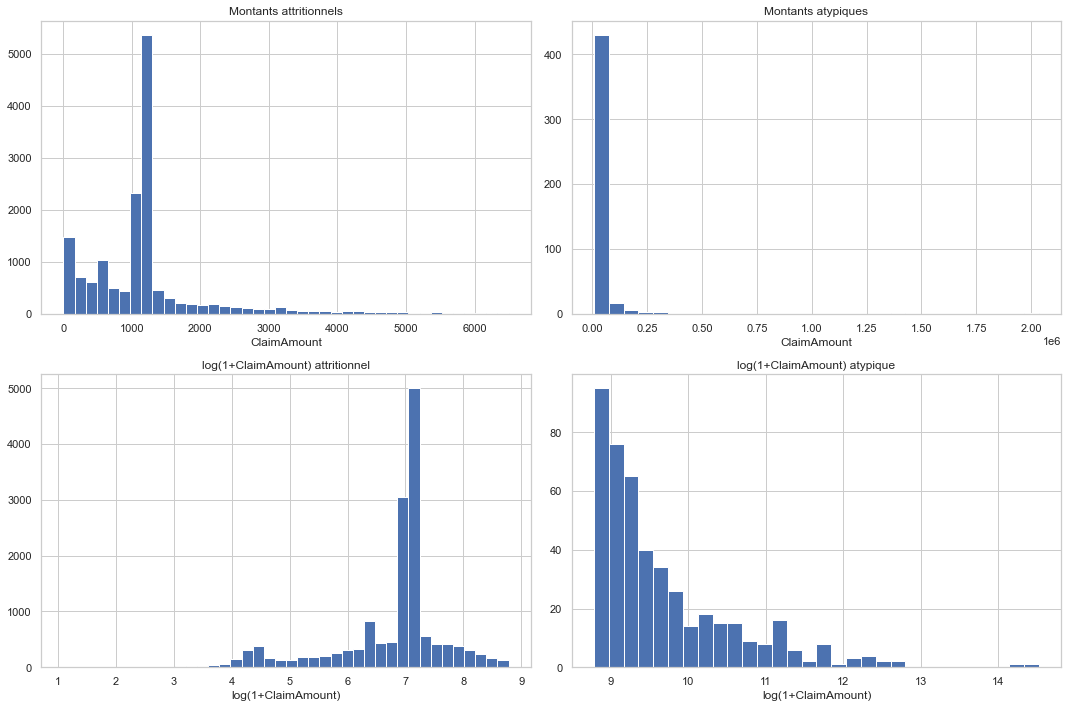

In [90]:

# 5. Histogrammes et transformations log

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(attr["ClaimAmount"], bins=40)
axes[0, 0].set_title("Montants attritionnels")
axes[0, 0].set_xlabel("ClaimAmount")

axes[0, 1].hist(atyp["ClaimAmount"], bins=30)
axes[0, 1].set_title("Montants atypiques")
axes[0, 1].set_xlabel("ClaimAmount")

axes[1, 0].hist(np.log1p(attr["ClaimAmount"]), bins=40)
axes[1, 0].set_title("log(1+ClaimAmount) attritionnel")
axes[1, 0].set_xlabel("log(1+ClaimAmount)")

axes[1, 1].hist(np.log1p(atyp["ClaimAmount"]), bins=30)
axes[1, 1].set_title("log(1+ClaimAmount) atypique")
axes[1, 1].set_xlabel("log(1+ClaimAmount)")

plt.tight_layout()
plt.show()



### Commentaireq

En général :
- les **attritionnels** restent asymétriques mais deviennent nettement plus réguliers après `log1p` ;
- les **atypiques** conservent une queue très lourde, même sur l'échelle log.

Cela suggère :
- pour les attritionnels : une modélisation ML sur cible `log(1+coût)` est raisonnable ;
- pour les atypiques : une logique de **théorie des valeurs extrêmes** est pertinente, avec un benchmark ML en complément.


L’analyse descriptive confirme que la séparation entre sinistres attritionnels et atypiques est pertinente. Les coûts attritionnels présentent une asymétrie modérée à droite, avec une moyenne proche de la médiane et une dispersion encore compatible avec une modélisation statistique classique, notamment après transformation logarithmique. À l’inverse, les coûts atypiques présentent une asymétrie extrême, une très forte kurtosis et une queue très lourde, avec quelques observations de très grande amplitude. Ces caractéristiques suggèrent de traiter les deux composantes par des approches distinctes : une modélisation prédictive classique ou semi-paramétrique pour les attritionnels, et une approche orientée valeurs extrêmes pour les atypiques.

In [91]:

# 6. Tableaux par classes : sévérité moyenne et dispersion

def grouped_stats(df, group_col, cost_col="ClaimAmount"):
    out = df.groupby(group_col)[cost_col].agg(
        n_obs="size",
        mean_cost="mean",
        median_cost="median",
        std_cost="std",
        q90=lambda x: np.quantile(x, 0.90),
        q95=lambda x: np.quantile(x, 0.95)
    )
    out["cv"] = out["std_cost"] / out["mean_cost"]
    return out.sort_values("mean_cost", ascending=False)

for col in ["DriverAge_cls", "CarAge_cls", "Density_cls", "Power_cls", "Brand_cls", "Region_cls", "Gas"]:
    print("\n" + "="*90)
    print(f"Attritionnel par {col}")
    display(grouped_stats(attr, col))

for col in ["DriverAge_cls", "CarAge_cls", "Density_cls", "Power_cls", "Brand_cls", "Region_cls", "Gas"]:
    print("\n" + "="*90)
    print(f"Atypique par {col}")
    display(grouped_stats(atyp, col))



Attritionnel par DriverAge_cls


,n_obs,mean_cost,median_cost,std_cost,q90,q95,cv
DriverAge_cls,,,,,,,
Jeunes conducteurs [16-30],2984,1208.305965,1148.0,978.655985,2232.4,3242.1,0.809941
Conducteurs seniors ]60-80],2107,1204.581870,1161.0,846.553374,1984.8,2838.9,0.702778
Conducteurs seniors actifs ]50-60],2983,1204.574925,1153.0,935.055624,2191.2,3183.2,0.776254
Conducteurs mûrs ]40-50],3935,1195.258704,1149.0,923.952792,2049.6,3119.2,0.773015
Conducteurs expérimentés ]30-40],3348,1183.397551,1145.0,957.187961,2191.3,3109.6,0.808847



Attritionnel par CarAge_cls


,n_obs,mean_cost,median_cost,std_cost,q90,q95,cv
CarAge_cls,,,,,,,
Véhicule récent [0-5],6080,1222.208882,1153.0,972.465122,2284.4,3241.05,0.795662
Véhicule intermédiaire ]5-10],4806,1208.061798,1145.0,964.434563,2235.0,3244.75,0.798332
Véhicule ancien ]15-20],970,1180.513402,1162.5,823.249207,1823.9,2805.85,0.697365
Véhicule âgé ]10-15],3501,1148.292202,1151.0,847.167212,1857.0,2766.00,0.737763



Attritionnel par Density_cls


...

,n_obs,mean_cost,median_cost,std_cost,q90,q95,cv
Brand_cls,,,,,,,
French_core,228,43974.881579,12219.0,166946.659389,65565.5,135427.65,3.796410
Germanic_mainstream,40,36790.600000,13537.5,66401.309549,68705.7,158598.40,1.804844
Other,12,32002.250000,10804.5,43443.558382,108752.5,121964.40,1.357516
US_Euro_mass,39,24200.641026,12318.0,25254.856091,69811.4,73170.00,1.043561
Premium_DE_US,28,21609.678571,10542.0,23248.995868,59177.2,67681.85,1.075860
Asia,92,17620.010870,9198.5,22214.400618,31802.5,66805.45,1.260748
Fiat,22,14009.727273,13459.5,6260.954675,21941.3,26117.25,0.446901



Atypique par Region_cls


,n_obs,mean_cost,median_cost,std_cost,q90,q95,cv
Region_cls,,,,,,,
C-B,233,47413.987124,13299.0,166861.657530,83655.2,163959.8,3.519250
PDL-BN-HN-LIM,58,22099.379310,13709.0,20674.395815,45318.5,63017.6,0.935519
IDF,77,19775.870130,9018.0,29071.686104,36766.2,68593.2,1.470059
PC-NPDC-AQUIT,93,16216.236559,10062.0,16596.844577,25092.2,66877.2,1.023471



Atypique par Gas


,n_obs,mean_cost,median_cost,std_cost,q90,q95,cv
Gas,,,,,,,
Regular,220,40904.290909,11638.5,167536.048796,67859.1,97807.5,4.095806
Diesel,241,26394.734440,10769.0,45516.046358,55077.0,92031.0,1.724437


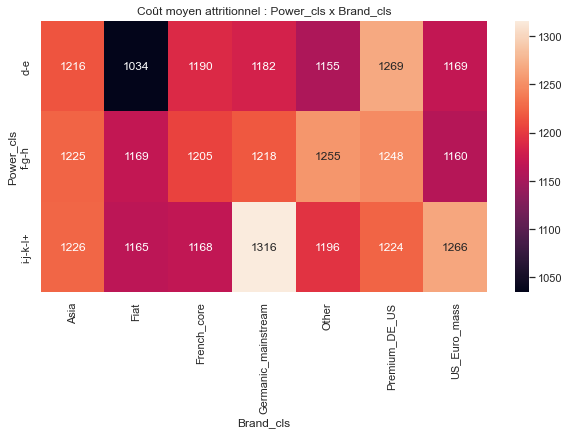

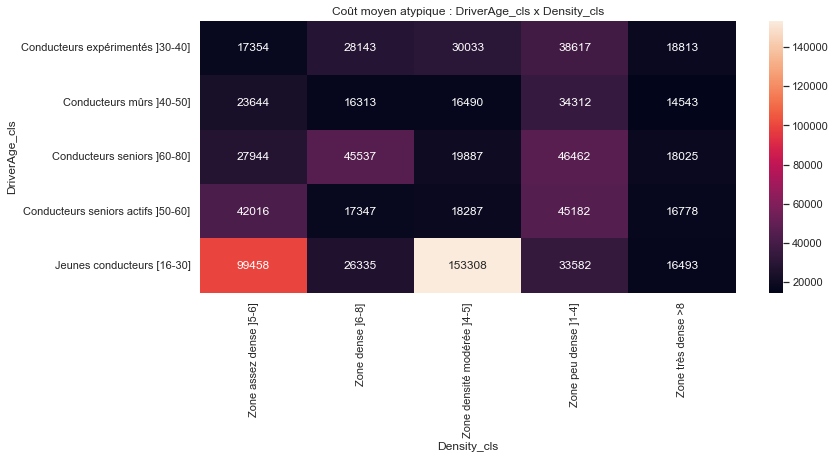

In [92]:

# 7. Heatmaps bivariées

# Attritionnel : coût moyen par croisement de variables
pivot_attr = attr.pivot_table(
    index="Power_cls", columns="Brand_cls",
    values="ClaimAmount", aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_attr, annot=True, fmt=".0f")
plt.title("Coût moyen attritionnel : Power_cls x Brand_cls")
plt.show()

# Atypique : coût moyen par croisement
pivot_atyp = atyp.pivot_table(
    index="DriverAge_cls", columns="Density_cls",
    values="ClaimAmount", aggfunc="mean"
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_atyp, annot=True, fmt=".0f")
plt.title("Coût moyen atypique : DriverAge_cls x Density_cls")
plt.show()


L’analyse croisée des coûts attritionnels selon la puissance et la marque met en évidence des écarts de coût moyen relativement modérés mais cohérents, suggérant une interaction possible entre ces deux variables. Cette structure peut être testée dans les modèles prédictifs comme variable croisée ou interaction.

À l’inverse, sur les sinistres atypiques, les écarts observés entre classes d’âge conducteur et niveaux de densité sont beaucoup plus marqués, mais doivent être interprétés avec prudence. En effet, la faible taille de l’échantillon atypique et la présence de valeurs extrêmes rendent les moyennes de cellule très sensibles à quelques observations. Ces résultats suggèrent une hétérogénéité réelle, mais insuffisamment stable pour être interprétée sans examen complémentaire des effectifs et de la robustesse des cellules.


# 3. Tests de lois

## 3.1 Attritionnels
Sur les attritionnels, on compare plusieurs familles positives classiques à but **descriptif** :
- Gamma ;
- Lognormale ;
- Weibull.

Le but n'est pas forcément de retenir une loi fermée comme modèle final, mais de vérifier si :
- l'échelle log semble adaptée ;
- la forme globale est compatible avec une modélisation continue asymétrique.


In [93]:

# 8. Ajustements de lois sur les attritionnels

def fit_and_compare_distributions(x):
    x = np.asarray(x)
    x = x[x > 0]
    results = []

    # Gamma
    g_par = gamma.fit(x, floc=0)
    g_ll = np.sum(gamma.logpdf(x, *g_par))
    results.append({
        "distribution": "Gamma",
        "params": g_par,
        "loglik": g_ll,
        "AIC": 2*len(g_par) - 2*g_ll,
        "KS_stat": stats.kstest(x, lambda z: gamma.cdf(z, *g_par)).statistic
    })

    # Lognormal
    ln_par = lognorm.fit(x, floc=0)
    ln_ll = np.sum(lognorm.logpdf(x, *ln_par))
    results.append({
        "distribution": "Lognormal",
        "params": ln_par,
        "loglik": ln_ll,
        "AIC": 2*len(ln_par) - 2*ln_ll,
        "KS_stat": stats.kstest(x, lambda z: lognorm.cdf(z, *ln_par)).statistic
    })

    # Weibull
    wb_par = weibull_min.fit(x, floc=0)
    wb_ll = np.sum(weibull_min.logpdf(x, *wb_par))
    results.append({
        "distribution": "Weibull",
        "params": wb_par,
        "loglik": wb_ll,
        "AIC": 2*len(wb_par) - 2*wb_ll,
        "KS_stat": stats.kstest(x, lambda z: weibull_min.cdf(z, *wb_par)).statistic
    })

    return pd.DataFrame(results).sort_values("AIC")

dist_attr = fit_and_compare_distributions(attr["ClaimAmount"])
display(dist_attr)


,distribution,params,loglik,AIC,KS_stat
2,Weibull,"(1.3332219177785871, 0, 1301.6181434773657)",-123272.075494,246550.150989,0.205789
0,Gamma,"(1.5852967905583832, 0, 755.8816808926259)",-123354.900976,246715.801953,0.220410
1,Lognormal,"(1.0056757473977487, 0.0, 846.604769617685)",-125402.685036,250811.370073,0.261404


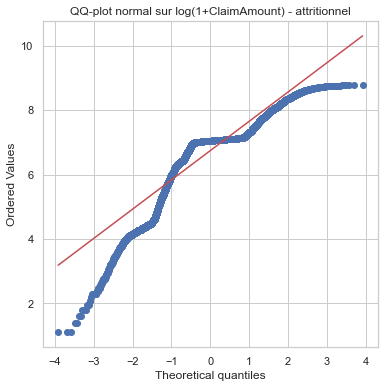

In [94]:

# QQ-plots simples sur l'échelle log pour les attritionnels
plt.figure(figsize=(6, 6))
stats.probplot(np.log1p(attr["ClaimAmount"]), dist="norm", plot=plt)
plt.title("QQ-plot normal sur log(1+ClaimAmount) - attritionnel")
plt.show()



## 3.2 Atypiques et EVT

Pour les atypiques, la logique naturelle est une **Peak Over Threshold (POT)** :

- seuil déjà retenu : \(u = 6500\) ;
- on modélise l'excès :
\[
Y = ClaimAmount - u \,|\, ClaimAmount > u
\]

et on ajuste une **loi de Pareto généralisée (GPD)**.

Cette approche est utile car :
- elle cible directement la queue ;
- elle est adaptée à une population peu nombreuse mais très lourde ;
- elle fournit un niveau de coût moyen attendu dans la queue.


In [95]:

# 9. EVT sur les atypiques : fit GPD sur les excès

u = 6500
atyp = atyp.copy()
atyp["Excess"] = atyp["ClaimAmount"] - u

# Ajustement GPD
shape_xi, loc_gpd, scale_beta = genpareto.fit(atyp["Excess"], floc=0)

print("Paramètres GPD")
print("xi (shape)  =", shape_xi)
print("loc         =", loc_gpd)
print("beta (scale)=", scale_beta)

if shape_xi < 1:
    mean_excess_evt = scale_beta / (1 - shape_xi)
    mean_amount_evt = u + mean_excess_evt
else:
    mean_excess_evt = np.inf
    mean_amount_evt = np.inf

print("Excès moyen EVT estimé :", mean_excess_evt)
print("Montant moyen atypique EVT estimé :", mean_amount_evt)


Paramètres GPD
xi (shape)  = 0.9890502223309661
loc         = 0
beta (scale)= 5268.684662747825
Excès moyen EVT estimé : 481168.1864233382
Montant moyen atypique EVT estimé : 487668.1864233382


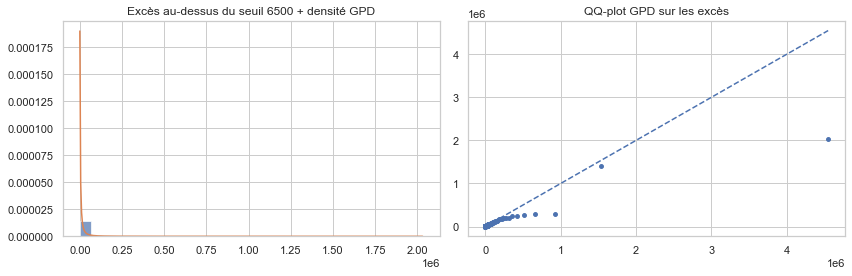

In [96]:

# Diagnostics visuels EVT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme des excès + densité GPD
x_grid = np.linspace(0, atyp["Excess"].max(), 400)
axes[0].hist(atyp["Excess"], bins=30, density=True, alpha=0.7)
axes[0].plot(x_grid, genpareto.pdf(x_grid, c=shape_xi, loc=0, scale=scale_beta))
axes[0].set_title("Excès au-dessus du seuil 6500 + densité GPD")

# QQ-plot empirique vs quantiles GPD
p = (np.arange(1, len(atyp)+1) - 0.5) / len(atyp)
emp_q = np.sort(atyp["Excess"].values)
theo_q = genpareto.ppf(p, c=shape_xi, loc=0, scale=scale_beta)

axes[1].scatter(theo_q, emp_q, s=15)
mx = max(theo_q.max(), emp_q.max())
axes[1].plot([0, mx], [0, mx], linestyle="--")
axes[1].set_title("QQ-plot GPD sur les excès")

plt.tight_layout()
plt.show()


L’ajustement d’une loi Generalized Pareto aux excès au-dessus du seuil met en évidence une queue extrêmement lourde, avec un paramètre de forme 
ξ proche de 1. Ce résultat confirme que les sinistres atypiques relèvent bien d’une logique de valeurs extrêmes. Toutefois, une telle valeur de 
ξ rend l’espérance conditionnelle très instable, car celle-ci devient extrêmement sensible à quelques observations exceptionnelles. Le QQ-plot montre d’ailleurs un écart dans la queue supérieure, ce qui suggère que les plus gros sinistres restent difficiles à ajuster correctement. En conséquence, l’EVT est très utile ici pour caractériser la lourdeur de la queue et justifier un traitement spécifique des atypiques, mais l’espérance GPD brute ne doit pas être utilisée sans précaution comme composante tarifaire directe.

In [97]:

# Test KS indicatif pour la GPD
ks_stat, ks_p = stats.kstest(
    atyp["Excess"].values,
    lambda z: genpareto.cdf(z, c=shape_xi, loc=0, scale=scale_beta)
)
print("KS GPD - stat :", ks_stat)
print("KS GPD - pvalue :", ks_p)


KS GPD - stat : 0.03193242385959727
KS GPD - pvalue : 0.7225274947039757


Le test de Kolmogorov-Smirnov appliqué aux excès au-dessus du seuil de 6500 ne conduit pas à rejeter l’ajustement par une loi Generalized Pareto (statistique KS = 0,0319 ; p-value = 0,7225). Ce résultat confirme que la modélisation des sinistres atypiques dans le cadre de la théorie des valeurs extrêmes est pertinente. La queue de distribution au-delà du seuil retenu peut donc être raisonnablement décrite par une GPD.

Néanmoins, le paramètre de forme estimé reste proche de 1, ce qui traduit une queue extrêmement lourde et rend l’espérance conditionnelle très sensible à quelques observations extrêmes. Ainsi, l’EVT valide bien la structure des atypiques, mais l’utilisation directe de l’espérance GPD comme coût moyen atypique doit rester prudente dans une optique tarifaire.


### Interprétation

- Si `xi > 0`, la queue est **lourde** ;
- si `xi < 1`, l'espérance théorique reste finie ;
- le fit GPD fournit une **référence actuarielle** utile pour la composante atypique.

**Limite** : une GPD globale ne tient pas compte des caractéristiques individuelles.  
C'est pourquoi on ajoute un **benchmark ML** sur les atypiques.



# 4. Modélisation des attritionnels

## Stratégie

Les attritionnels ont :
- un effectif suffisant ;
- une asymétrie modérée après séparation ;
- une cible positive mais relativement régulière après `log1p`.

On va comparer :

1. **Baseline** : moyenne / médiane globale ;
2. **HistGradientBoosting** sur `log1p(ClaimAmount)` ;
3. **CatBoost** sur `log1p(ClaimAmount)` ;
4. **CatBoost avec variables croisées**.

Les métriques seront calculées **sur l'échelle originale du coût** :
- RMSE ;
- MAE ;
- MAPE tronquée (indicative).


In [98]:

# 10. Préparation train / test attritionnel

attr_model = attr.copy()

X_attr_base = attr_model[FEATURES_BASE]
X_attr_int = attr_model[FEATURES_INT]
y_attr = attr_model["ClaimAmount"]

X_train_ab, X_test_ab, y_train_a, y_test_a = train_test_split(
    X_attr_base, y_attr, test_size=0.2, random_state=RANDOM_STATE
)
X_train_ai, X_test_ai, _, _ = train_test_split(
    X_attr_int, y_attr, test_size=0.2, random_state=RANDOM_STATE
)

print(X_train_ab.shape, X_test_ab.shape)


(12285, 15) (3072, 15)


In [99]:
# Préprocesseur dense pour HistGradientBoosting
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

prep_base = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", cat_pipe, BASE_CAT)
])

prep_int = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", cat_pipe, BASE_CAT + INTER_CAT)
])

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def mape_trimmed(y_true, y_pred, floor=50):
    yt = np.maximum(np.asarray(y_true), floor)
    yp = np.asarray(y_pred)
    return np.mean(np.abs((yt - yp) / yt))

def evaluate_regression(y_true, y_pred, name):
    return {
        "model": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE_trim50": mape_trimmed(y_true, y_pred),
        "Mean_true": np.mean(y_true),
        "Mean_pred": np.mean(y_pred)
    }

In [100]:

# 11. Baseline attritionnelle

pred_mean = np.repeat(y_train_a.mean(), len(y_test_a))
pred_median = np.repeat(y_train_a.median(), len(y_test_a))

attr_results = []
attr_results.append(evaluate_regression(y_test_a, pred_mean, "Baseline_mean"))
attr_results.append(evaluate_regression(y_test_a, pred_median, "Baseline_median"))
pd.DataFrame(attr_results)


,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,Baseline_mean,904.543702,520.115223,1.888146,1190.708659,1200.194302
1,Baseline_median,905.321872,511.784831,1.805473,1190.708659,1152.000000


In [101]:

# 12. HistGradientBoosting sur log1p(ClaimAmount)

hgb_attr = Pipeline([
    ("prep", prep_base),
    ("model", HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=80,
        random_state=RANDOM_STATE
    ))
])

hgb_attr.fit(X_train_ab, np.log1p(y_train_a))
pred_hgb = np.expm1(hgb_attr.predict(X_test_ab))
pred_hgb = np.clip(pred_hgb, 0, None)

attr_results.append(evaluate_regression(y_test_a, pred_hgb, "HGB_log_base"))
pd.DataFrame(attr_results).sort_values("RMSE")


,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,Baseline_mean,904.543702,520.115223,1.888146,1190.708659,1200.194302
1,Baseline_median,905.321872,511.784831,1.805473,1190.708659,1152.000000
2,HGB_log_base,966.152408,613.333866,1.401598,1190.708659,854.340157


In [102]:

# 13. Random Forest attritionnel - base

rf_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_attr_base.fit(X_train_ab, np.log1p(y_train_a))

pred_rf_base = np.expm1(rf_attr_base.predict(X_test_ab))
pred_rf_base = np.clip(pred_rf_base, 0, None)

attr_results.append(
    evaluate_regression(y_test_a, pred_rf_base, "RF_log_base")
)
pd.DataFrame(attr_results).sort_values("RMSE")

,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,Baseline_mean,904.543702,520.115223,1.888146,1190.708659,1200.194302
1,Baseline_median,905.321872,511.784831,1.805473,1190.708659,1152.000000
2,HGB_log_base,966.152408,613.333866,1.401598,1190.708659,854.340157
3,RF_log_base,966.782029,613.380353,1.398374,1190.708659,856.569103


In [103]:

# 14. HistGradientBoosting attritionnel avec interactions explicites

hgb_attr_int = Pipeline([
    ("prep", prep_int),
    ("model", HistGradientBoostingRegressor(
        max_iter=600,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=30,
        random_state=RANDOM_STATE
    ))
])

hgb_attr_int.fit(X_train_ai, np.log1p(y_train_a))

pred_hgb_int = np.expm1(hgb_attr_int.predict(X_test_ai))
pred_hgb_int = np.clip(pred_hgb_int, 0, None)

attr_results.append(
    evaluate_regression(y_test_a, pred_hgb_int, "HGB_log_interactions")
)
attr_results_df = pd.DataFrame(attr_results).sort_values("RMSE")
display(attr_results_df)

,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,Baseline_mean,904.543702,520.115223,1.888146,1190.708659,1200.194302
1,Baseline_median,905.321872,511.784831,1.805473,1190.708659,1152.000000
4,HGB_log_interactions,966.077185,613.875280,1.403013,1190.708659,854.142175
2,HGB_log_base,966.152408,613.333866,1.401598,1190.708659,854.340157
3,RF_log_base,966.782029,613.380353,1.398374,1190.708659,856.569103


In [104]:

# Modélisation attritionnelle - fonction utilitaire + tous les modèles
# Baselines, RF, HGB, GradientBoosting, XGBoost, LightGBM
# Versions log + interactions, et versions coût brut


# Imports complémentaires si besoin
from sklearn.ensemble import GradientBoostingRegressor

# Décommente si nécessaire
# !pip install xgboost lightgbm

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Fonction utilitaire : correction de retransformation (smearing)

def predict_with_smearing_log_model(fitted_model, X_train, y_train, X_test):
    """
    fitted_model : modèle déjà entraîné sur log1p(y)
    Retourne des prédictions sur l'échelle brute avec correction de retransformation.
    """
    log_pred_train = fitted_model.predict(X_train)
    smear = np.mean((1 + np.asarray(y_train)) / np.exp(log_pred_train))
    pred = smear * np.exp(fitted_model.predict(X_test)) - 1
    return np.clip(pred, 0, None)


# Vérification des objets attendus

required_objects = [
    "X_train_ab", "X_test_ab", "X_train_ai", "X_test_ai",
    "y_train_a", "y_test_a",
    "prep_base", "prep_int",
    "attr_results", "RANDOM_STATE"
]
missing = [obj for obj in required_objects if obj not in globals()]
if len(missing) > 0:
    raise ValueError(f"Objets manquants avant exécution : {missing}")

# 1. Baselines

pred_mean = np.repeat(np.mean(y_train_a), len(y_test_a))
pred_median = np.repeat(np.median(y_train_a), len(y_test_a))

attr_results.append(
    evaluate_regression(y_test_a, pred_mean, "Baseline_mean")
)
attr_results.append(
    evaluate_regression(y_test_a, pred_median, "Baseline_median")
)


# 2. Random Forest - log - base

rf_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_attr_base.fit(X_train_ab, np.log1p(y_train_a))
pred_rf_base = predict_with_smearing_log_model(
    rf_attr_base, X_train_ab, y_train_a, X_test_ab
)

attr_results.append(
    evaluate_regression(y_test_a, pred_rf_base, "RF_log_base")
)


# 3. HistGradientBoosting - log - base

hgb_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=30,
        random_state=RANDOM_STATE
    ))
])

hgb_attr_base.fit(X_train_ab, np.log1p(y_train_a))
pred_hgb_base = predict_with_smearing_log_model(
    hgb_attr_base, X_train_ab, y_train_a, X_test_ab
)

attr_results.append(
    evaluate_regression(y_test_a, pred_hgb_base, "HGB_log_base")
)


# 4. HistGradientBoosting - log - interactions

hgb_attr_int = Pipeline([
    ("prep", prep_int),
    ("model", HistGradientBoostingRegressor(
        max_iter=600,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=30,
        random_state=RANDOM_STATE
    ))
])

hgb_attr_int.fit(X_train_ai, np.log1p(y_train_a))
pred_hgb_int = predict_with_smearing_log_model(
    hgb_attr_int, X_train_ai, y_train_a, X_test_ai
)

attr_results.append(
    evaluate_regression(y_test_a, pred_hgb_int, "HGB_log_interactions")
)


# 5. GradientBoosting - log - base

gbr_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gbr_attr_base.fit(X_train_ab, np.log1p(y_train_a))
pred_gbr_base = predict_with_smearing_log_model(
    gbr_attr_base, X_train_ab, y_train_a, X_test_ab
)

attr_results.append(
    evaluate_regression(y_test_a, pred_gbr_base, "GBR_log_base")
)


# 6. GradientBoosting - log - interactions

gbr_attr_int = Pipeline([
    ("prep", prep_int),
    ("model", GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gbr_attr_int.fit(X_train_ai, np.log1p(y_train_a))
pred_gbr_int = predict_with_smearing_log_model(
    gbr_attr_int, X_train_ai, y_train_a, X_test_ai
)

attr_results.append(
    evaluate_regression(y_test_a, pred_gbr_int, "GBR_log_interactions")
)


# 7. XGBoost - log - base

xgb_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_attr_base.fit(X_train_ab, np.log1p(y_train_a))
pred_xgb_base = predict_with_smearing_log_model(
    xgb_attr_base, X_train_ab, y_train_a, X_test_ab
)

attr_results.append(
    evaluate_regression(y_test_a, pred_xgb_base, "XGB_log_base")
)


# 8. XGBoost - log - interactions

xgb_attr_int = Pipeline([
    ("prep", prep_int),
    ("model", XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_attr_int.fit(X_train_ai, np.log1p(y_train_a))
pred_xgb_int = predict_with_smearing_log_model(
    xgb_attr_int, X_train_ai, y_train_a, X_test_ai
)

attr_results.append(
    evaluate_regression(y_test_a, pred_xgb_int, "XGB_log_interactions")
)


# 9. LightGBM - log - base

lgbm_attr_base = Pipeline([
    ("prep", prep_base),
    ("model", LGBMRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_attr_base.fit(X_train_ab, np.log1p(y_train_a))
pred_lgbm_base = predict_with_smearing_log_model(
    lgbm_attr_base, X_train_ab, y_train_a, X_test_ab
)

attr_results.append(
    evaluate_regression(y_test_a, pred_lgbm_base, "LGBM_log_base")
)


# 10. LightGBM - log - interactions

lgbm_attr_int = Pipeline([
    ("prep", prep_int),
    ("model", LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_attr_int.fit(X_train_ai, np.log1p(y_train_a))
pred_lgbm_int = predict_with_smearing_log_model(
    lgbm_attr_int, X_train_ai, y_train_a, X_test_ai
)

attr_results.append(
    evaluate_regression(y_test_a, pred_lgbm_int, "LGBM_log_interactions")
)


# 11. XGBoost - coût brut - base

xgb_attr_raw = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_attr_raw.fit(X_train_ab, y_train_a)
pred_xgb_raw = np.clip(xgb_attr_raw.predict(X_test_ab), 0, None)

attr_results.append(
    evaluate_regression(y_test_a, pred_xgb_raw, "XGB_raw_base")
)


# 12. LightGBM - coût brut - base

lgbm_attr_raw = Pipeline([
    ("prep", prep_base),
    ("model", LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_attr_raw.fit(X_train_ab, y_train_a)
pred_lgbm_raw = np.clip(lgbm_attr_raw.predict(X_test_ab), 0, None)

attr_results.append(
    evaluate_regression(y_test_a, pred_lgbm_raw, "LGBM_raw_base")
)


# 13. GradientBoosting - coût brut - base

gbr_attr_raw = Pipeline([
    ("prep", prep_base),
    ("model", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gbr_attr_raw.fit(X_train_ab, y_train_a)
pred_gbr_raw = np.clip(gbr_attr_raw.predict(X_test_ab), 0, None)

attr_results.append(
    evaluate_regression(y_test_a, pred_gbr_raw, "GBR_raw_base")
)


# 14. Résultats finaux triés

attr_results_df = pd.DataFrame(attr_results).drop_duplicates(subset=["model"], keep="last")
attr_results_df = attr_results_df.sort_values("RMSE").reset_index(drop=True)

display(attr_results_df)
print("\nMeilleur modèle selon RMSE :", attr_results_df.iloc[0]["model"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 816
[LightGBM] [Info] Number of data points in the train set: 12285, number of used features: 64
[LightGBM] [Info] Start training from score 6.743705
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,Baseline_mean,904.543702,520.115223,1.888146,1190.708659,1200.194302
1,XGB_raw_base,905.309478,552.248120,1.899917,1190.708659,1197.760254
2,Baseline_median,905.321872,511.784831,1.805473,1190.708659,1152.000000
3,HGB_log_base,908.906508,551.448535,1.867204,1190.708659,1193.835332
4,HGB_log_interactions,909.064275,551.644278,1.863578,1190.708659,1193.222436
5,GBR_raw_base,910.903570,563.274291,1.910552,1190.708659,1198.703466
6,LGBM_raw_base,911.566190,562.955337,1.912393,1190.708659,1200.216247
7,RF_log_base,913.006591,558.996300,1.812228,1190.708659,1162.690435
8,XGB_log_base,916.935894,570.207215,1.851898,1190.708659,1179.879272
9,XGB_log_interactions,921.000162,574.850291,1.854003,1190.708659,1176.941284



Meilleur modèle selon RMSE : Baseline_mean


### Conclusion et synthèse — Sévérité attritionnelle

L’étude de la sévérité attritionnelle a montré que, malgré plusieurs analyses descriptives, segmentations et essais de modélisation avancée, les variables disponibles expliquent relativement peu le montant individuel d’un sinistre attritionnel. Ce constat est cohérent avec les résultats obtenus précédemment par le GLM Gamma, qui montraient déjà un faible pouvoir discriminant des variables sur la composante coût.

Plusieurs approches de machine learning ont été testées : Random Forest, HistGradientBoosting, Gradient Boosting, XGBoost et LightGBM, avec différentes variantes en coût brut, en transformation logarithmique et avec interactions explicites. Les résultats obtenus montrent qu’aucun modèle ne surpasse clairement la baseline constituée par la moyenne globale des coûts attritionnels en termes de RMSE. En revanche, parmi les modèles testés, XGBoost sur coût brut (XGB_raw_base) apparaît comme le meilleur modèle de machine learning, avec des performances très proches de la baseline.

Ce résultat est intéressant à deux niveaux. D’une part, il confirme que la structure explicative contenue dans les variables disponibles reste limitée pour prédire finement le coût attritionnel. D’autre part, le fait que XGBoost atteigne un niveau presque équivalent à la baseline suggère qu’il capte malgré tout une partie de l’hétérogénéité résiduelle du portefeuille. Ainsi, même s’il n’apporte pas encore un gain net avec les données actuelles, il constitue le meilleur candidat pour la suite, car il est raisonnable de penser qu’avec davantage d’observations, des variables plus riches et des informations plus directement liées au sinistre, ce type de modèle pourrait dépasser plus nettement la moyenne globale.

En conséquence, pour la poursuite du travail et afin de disposer d’une composante attritionnelle individualisée, nous retenons XGB_raw_base comme modèle final de sévérité attritionnelle. Ce choix permet de conserver une approche moderne, flexible et potentiellement extensible, tout en gardant à l’esprit que son avantage reste pour l’instant marginal compte tenu de l’information disponible dans la base.

In [105]:

# Modèle final retenu pour les attritionnels : XGB_raw_base
# Réentraînement sur toute la base attritionnelle
# + calcul des prédictions attritionnelles


# 1. Définition du modèle final
final_attr_model = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# 2. Réentraînement sur toute la base attritionnelle
X_attr_full = attr_model[FEATURES_BASE].copy()
y_attr_full = attr_model["ClaimAmount"].copy()

final_attr_model.fit(X_attr_full, y_attr_full)

# 3. Prédictions sur la base attritionnelle elle-même
attr_model_pred = attr_model.copy()
attr_model_pred["pred_claim_attritionnel"] = np.clip(
    final_attr_model.predict(X_attr_full),
    0,
    None
)

# 4. Résumé des prédictions
print("Résumé des prédictions attritionnelles :")
display(
    attr_model_pred["pred_claim_attritionnel"].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("Coût moyen observé :", attr_model_pred["ClaimAmount"].mean())
print("Coût moyen prédit   :", attr_model_pred["pred_claim_attritionnel"].mean())

# 5. Évaluation in-sample (à ne pas confondre avec la validation)
attr_in_sample_metrics = pd.DataFrame([{
    "RMSE_in_sample": rmse(attr_model_pred["ClaimAmount"], attr_model_pred["pred_claim_attritionnel"]),
    "MAE_in_sample": mean_absolute_error(attr_model_pred["ClaimAmount"], attr_model_pred["pred_claim_attritionnel"]),
    "Mean_true": attr_model_pred["ClaimAmount"].mean(),
    "Mean_pred": attr_model_pred["pred_claim_attritionnel"].mean()
}])

display(attr_in_sample_metrics)

# 6. Export éventuel
attr_model_pred.to_csv("cout_attritionnel_predictions_xgb.csv", index=False)

print("Fichier exporté : cout_attritionnel_predictions_xgb.csv")

Résumé des prédictions attritionnelles :


count    15357.000000
mean      1197.751953
std        168.052505
min        708.746399
50%       1175.378052
75%       1277.448364
90%       1396.419238
95%       1490.857812
99%       1749.563848
max       2929.792969
Name: pred_claim_attritionnel, dtype: float64

Coût moyen observé : 1198.2968027609559
Coût moyen prédit   : 1197.751953125


,RMSE_in_sample,MAE_in_sample,Mean_true,Mean_pred
0,886.504743,538.684508,1198.296803,1197.751953


Fichier exporté : cout_attritionnel_predictions_xgb.csv



# 5. Modélisation des atypiques

## Stratégie

L'effectif atypique est faible (~ quelques centaines de sinistres), donc :

- une approche purement ML peut être instable ;
- une approche purement EVT est solide sur la queue, mais peu individualisée.

On compare donc :
1. **EVT global (GPD)** sur les excès ;
2. **CatBoost sur le log-excès** ;
3. éventuellement une **combinaison** des deux si le ML apporte un gain sans dérive.

Le coût atypique prédit sera ensuite combiné à la probabilité d'être atypique.


In [106]:

# 17. Train / test atypiques

atyp_model = atyp.copy()

X_atyp_base = atyp_model[FEATURES_BASE]
X_atyp_int = atyp_model[FEATURES_INT]
y_atyp = atyp_model["ClaimAmount"]
y_excess = atyp_model["ClaimAmount"] - u

X_train_tb, X_test_tb, y_train_t, y_test_t = train_test_split(
    X_atyp_base, y_atyp, test_size=0.2, random_state=RANDOM_STATE
)
X_train_ti, X_test_ti, _, _ = train_test_split(
    X_atyp_int, y_atyp, test_size=0.2, random_state=RANDOM_STATE
)

print(X_train_tb.shape, X_test_tb.shape)


(368, 15) (93, 15)


In [107]:

# 18. Baseline EVT atypique

# Ajustement GPD uniquement sur l'échantillon train
train_excess = y_train_t - u
shape_tr, loc_tr, scale_tr = genpareto.fit(train_excess, floc=0)

if shape_tr < 1:
    pred_evt_mean = u + scale_tr / (1 - shape_tr)
else:
    pred_evt_mean = np.median(y_train_t)

pred_evt = np.repeat(pred_evt_mean, len(y_test_t))

atyp_results = []
atyp_results.append(evaluate_regression(y_test_t, pred_evt, "EVT_global_mean"))
pd.DataFrame(atyp_results)


,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,EVT_global_mean,75225.50781,72153.172545,7.164934,25630.0,90809.228439


In [108]:

# Modélisation des atypiques - plusieurs modèles
# Surcoût au-dessus du seuil u
# Baselines, RF, HGB, GBR, XGB, LGBM
# Versions log(excès) et brut(excès)


from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Vérifications minimales

required_objects = [
    "X_train_tb", "X_test_tb", "y_train_t", "y_test_t",
    "prep_base", "RANDOM_STATE", "evaluate_regression"
]
missing = [obj for obj in required_objects if obj not in globals()]
if len(missing) > 0:
    raise ValueError(f"Objets manquants avant exécution : {missing}")

# seuil atypique
u = 6500

# si atyp_results n'existe pas encore
if "atyp_results" not in globals():
    atyp_results = []


# Fonction utilitaire : correction de retransformation
# pour modèles appris sur log1p(excès)

def predict_with_smearing_log_excess_model(fitted_model, X_train, y_train, X_test, u=6500):
    """
    fitted_model entraîné sur log1p(y - u)
    Renvoie des prédictions sur l'échelle brute du coût total.
    """
    excess_train = np.asarray(y_train) - u
    excess_train = np.clip(excess_train, 0, None)

    log_pred_train = fitted_model.predict(X_train)
    smear = np.mean((1 + excess_train) / np.exp(log_pred_train))

    pred_excess = smear * np.exp(fitted_model.predict(X_test)) - 1
    pred_excess = np.clip(pred_excess, 0, None)

    pred_total = u + pred_excess
    return np.clip(pred_total, u, None)


# Fonction baseline sur excès

def baseline_excess_prediction(y_train, n_test, strategy="mean", u=6500):
    excess_train = np.asarray(y_train) - u
    excess_train = np.clip(excess_train, 0, None)

    if strategy == "mean":
        pred_excess = np.repeat(np.mean(excess_train), n_test)
    elif strategy == "median":
        pred_excess = np.repeat(np.median(excess_train), n_test)
    else:
        raise ValueError("strategy doit être 'mean' ou 'median'")

    return u + pred_excess


# 1. Baselines atypiques

pred_atyp_mean = baseline_excess_prediction(y_train_t, len(y_test_t), strategy="mean", u=u)
pred_atyp_median = baseline_excess_prediction(y_train_t, len(y_test_t), strategy="median", u=u)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_mean, "Baseline_excess_mean")
)
atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_median, "Baseline_excess_median")
)


# 2. Random Forest - log(excès)

rf_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))
pred_atyp_rf_log = predict_with_smearing_log_excess_model(
    rf_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_rf_log, "RF_excess_log_base")
)


# 3. HistGradientBoosting - log(excès)

hgb_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ))
])

hgb_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))
pred_atyp_hgb_log = predict_with_smearing_log_excess_model(
    hgb_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_hgb_log, "HGB_excess_log_base")
)


# 4. GradientBoosting - log(excès)

gbr_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=8,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gbr_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))
pred_atyp_gbr_log = predict_with_smearing_log_excess_model(
    gbr_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_gbr_log, "GBR_excess_log_base")
)


# 5. XGBoost - log(excès)

xgb_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))
pred_atyp_xgb_log = predict_with_smearing_log_excess_model(
    xgb_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_xgb_log, "XGB_excess_log_base")
)


# 6. LightGBM - log(excès)

lgbm_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", LGBMRegressor(
        n_estimators=350,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))
pred_atyp_lgbm_log = predict_with_smearing_log_excess_model(
    lgbm_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_lgbm_log, "LGBM_excess_log_base")
)


# 7. XGBoost - excès brut

xgb_atyp_raw = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_raw.fit(X_train_tb, np.clip(y_train_t - u, 0, None))
pred_atyp_xgb_raw = u + np.clip(xgb_atyp_raw.predict(X_test_tb), 0, None)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_xgb_raw, "XGB_excess_raw_base")
)


# 8. LightGBM - excès brut

lgbm_atyp_raw = Pipeline([
    ("prep", prep_base),
    ("model", LGBMRegressor(
        n_estimators=350,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_atyp_raw.fit(X_train_tb, np.clip(y_train_t - u, 0, None))
pred_atyp_lgbm_raw = u + np.clip(lgbm_atyp_raw.predict(X_test_tb), 0, None)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_lgbm_raw, "LGBM_excess_raw_base")
)


# 9. GradientBoosting - excès brut

gbr_atyp_raw = Pipeline([
    ("prep", prep_base),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=8,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gbr_atyp_raw.fit(X_train_tb, np.clip(y_train_t - u, 0, None))
pred_atyp_gbr_raw = u + np.clip(gbr_atyp_raw.predict(X_test_tb), 0, None)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_gbr_raw, "GBR_excess_raw_base")
)


# 10. Random Forest - excès brut

rf_atyp_raw = Pipeline([
    ("prep", prep_base),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_atyp_raw.fit(X_train_tb, np.clip(y_train_t - u, 0, None))
pred_atyp_rf_raw = u + np.clip(rf_atyp_raw.predict(X_test_tb), 0, None)

atyp_results.append(
    evaluate_regression(y_test_t, pred_atyp_rf_raw, "RF_excess_raw_base")
)


# 11. Tableau final

atyp_results_df = pd.DataFrame(atyp_results).drop_duplicates(subset=["model"], keep="last")
atyp_results_df = atyp_results_df.sort_values("RMSE").reset_index(drop=True)

display(atyp_results_df)

print("\nMeilleur modèle atypique selon RMSE :", atyp_results_df.iloc[0]["model"])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 368, number of used features: 56
[LightGBM] [Info] Start training from score 8.653433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 368, number of used features: 56
[LightGBM] [Info] Start training from score 28762.187500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,model,RMSE,MAE,MAPE_trim50,Mean_true,Mean_pred
0,LGBM_excess_log_base,37477.995281,20404.369036,0.951380,25630.0,20386.474080
1,XGB_excess_log_base,37495.671489,21062.072539,1.078864,25630.0,21360.562500
2,HGB_excess_log_base,37523.672453,19876.215995,0.844122,25630.0,18844.198170
3,RF_excess_log_base,37714.538997,22287.093631,1.278535,25630.0,23533.798623
4,GBR_excess_log_base,38427.301860,20901.810058,1.006288,25630.0,19974.057080
5,Baseline_excess_mean,38772.725483,29986.897177,2.334946,25630.0,35262.187500
6,Baseline_excess_median,40078.763424,17989.618280,0.483912,25630.0,11638.500000
7,GBR_excess_raw_base,44040.057209,26944.151908,1.595228,25630.0,28829.537146
8,LGBM_excess_raw_base,45861.801178,28964.110936,1.820250,25630.0,31093.857268
9,RF_excess_raw_base,47005.561802,29675.313337,1.892528,25630.0,33514.418633



Meilleur modèle atypique selon RMSE : LGBM_excess_log_base


Les essais de modélisation sur les sinistres atypiques montrent un résultat très différent de celui observé sur les attritionnels. Alors que la sévérité attritionnelle était difficile à améliorer par rapport à une simple moyenne, les atypiques bénéficient clairement de méthodes de machine learning plus flexibles. Les meilleurs résultats sont obtenus par les modèles ajustés sur le logarithme de l’excès au-dessus du seuil, ce qui confirme l’intérêt de transformer la variable cible pour stabiliser une distribution très asymétrique. Parmi les approches testées, XGBoost sur log-excès apparaît comme le meilleur modèle selon le RMSE.

En parallèle, l’approche EVT/GPD reste utile pour caractériser la queue de distribution et justifier le traitement spécifique des sinistres atypiques, mais elle se révèle moins performante comme outil de prédiction individuelle brute. En conséquence, pour la composante atypique du coût, nous retenons XGB_excess_log_base comme modèle prédictif principal, tandis que l’EVT conserve un rôle d’appui théorique pour l’analyse du risque extrême.


### Commentaires

Sur les atypiques, la performance restera mécaniquement plus bruitée que sur les attritionnels :
- faible effectif ;
- très forte dispersion ;
- queue lourde.

Si le modèle ML bat l'EVT en validation, on peut le retenir.  
Sinon, l'EVT reste une très bonne base pour une **surprime atypique**.


In [109]:

# Comparaison XGB log-excès vs métriques EVT / robustes

from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from xgboost import XGBRegressor

u = 6500


# 1. Fonction utilitaire

def predict_with_smearing_log_excess_model(fitted_model, X_train, y_train, X_test, u=6500):
    excess_train = np.asarray(y_train) - u
    excess_train = np.clip(excess_train, 0, None)

    log_pred_train = fitted_model.predict(X_train)
    smear = np.mean((1 + excess_train) / np.exp(log_pred_train))

    pred_excess = smear * np.exp(fitted_model.predict(X_test)) - 1
    pred_excess = np.clip(pred_excess, 0, None)

    pred_total = u + pred_excess
    return np.clip(pred_total, u, None)


# 2. Fonctions EVT / métriques robustes

def empirical_tvar(x, alpha=0.95):
    x = np.asarray(x)
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

def gpd_quantile(alpha, xi, beta, u):
    """
    Quantile de la loi des excès au-dessus de u.
    alpha doit être dans (0,1), quantile conditionnel parmi les atypiques.
    """
    alpha = np.clip(alpha, 1e-8, 1 - 1e-8)
    if abs(xi) < 1e-8:
        exc_q = -beta * np.log(1 - alpha)
    else:
        exc_q = beta / xi * ((1 - alpha) ** (-xi) - 1)
    return u + exc_q

def gpd_tvar(alpha, xi, beta, u):
    """
    TVaR conditionnelle approximative au niveau alpha pour une GPD sur les excès.
    Valable seulement si xi < 1.
    """
    q = gpd_quantile(alpha, xi, beta, u)
    if xi >= 1:
        return np.nan
    # ES pour GPD des excès au-dessus du seuil de quantile
    # ES_alpha = q + (beta + xi*(q-u)) / (1 - xi)
    return q + (beta + xi * (q - u)) / (1 - xi)

def summarize_distribution(x, prefix="obs"):
    x = np.asarray(x)
    out = {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_median": np.median(x),
        f"{prefix}_q50": np.quantile(x, 0.50),
        f"{prefix}_q75": np.quantile(x, 0.75),
        f"{prefix}_q90": np.quantile(x, 0.90),
        f"{prefix}_q95": np.quantile(x, 0.95),
        f"{prefix}_q99": np.quantile(x, 0.99),
        f"{prefix}_tvar90": empirical_tvar(x, 0.90),
        f"{prefix}_tvar95": empirical_tvar(x, 0.95),
    }
    return out


# 3. Réentraînement XGB log-excès et prédictions test

xgb_atyp_log = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_log.fit(X_train_tb, np.log1p(np.clip(y_train_t - u, 0, None)))

pred_xgb_test = predict_with_smearing_log_excess_model(
    xgb_atyp_log, X_train_tb, y_train_t, X_test_tb, u=u
)


# 4. Références EVT globales
#    On suppose que tu as déjà estimé xi_gpd et beta_gpd.
#    Si ce n'est pas le cas, on les ré-estime ici sur train.

train_excess = np.clip(np.asarray(y_train_t) - u, 0, None)

# Ajustement GPD sur les excès du train
xi_gpd, loc_gpd, beta_gpd = genpareto.fit(train_excess, floc=0)

print("Paramètres GPD estimés sur train :")
print("xi (shape) =", xi_gpd)
print("beta (scale) =", beta_gpd)

# Baselines EVT / robustes constantes
evt_mean_pred = np.repeat(u + np.mean(train_excess), len(y_test_t))
evt_median_pred = np.repeat(u + np.median(train_excess), len(y_test_t))
evt_q90_pred = np.repeat(gpd_quantile(0.90, xi_gpd, beta_gpd, u), len(y_test_t))
evt_q95_pred = np.repeat(gpd_quantile(0.95, xi_gpd, beta_gpd, u), len(y_test_t))
evt_q99_pred = np.repeat(gpd_quantile(0.99, xi_gpd, beta_gpd, u), len(y_test_t))

evt_tvar90_value = gpd_tvar(0.90, xi_gpd, beta_gpd, u)
evt_tvar95_value = gpd_tvar(0.95, xi_gpd, beta_gpd, u)

evt_tvar90_pred = np.repeat(evt_tvar90_value, len(y_test_t))
evt_tvar95_pred = np.repeat(evt_tvar95_value, len(y_test_t))


# 5. Fonction d'évaluation enrichie

def evaluate_extreme_model(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    res = {
        "model": model_name,
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "Mean_true": np.mean(y_true),
        "Mean_pred": np.mean(y_pred),
    }

    # Résumé distribution observée et prédite
    obs_stats = summarize_distribution(y_true, prefix="obs")
    pred_stats = summarize_distribution(y_pred, prefix="pred")
    res.update(obs_stats)
    res.update(pred_stats)

    # Erreurs relatives sur quantiles et TVaR
    for level in ["q50", "q75", "q90", "q95", "q99", "tvar90", "tvar95"]:
        obs_val = res[f"obs_{level}"]
        pred_val = res[f"pred_{level}"]
        if np.isfinite(obs_val) and abs(obs_val) > 1e-12:
            res[f"rel_err_{level}"] = (pred_val - obs_val) / obs_val
        else:
            res[f"rel_err_{level}"] = np.nan

    return res


# 6. Comparaison

extreme_compare = []

# Modèle XGB
extreme_compare.append(
    evaluate_extreme_model(y_test_t, pred_xgb_test, "XGB_excess_log_base")
)

# Références robustes / EVT
extreme_compare.append(
    evaluate_extreme_model(y_test_t, evt_mean_pred, "Empirical_excess_mean_train")
)
extreme_compare.append(
    evaluate_extreme_model(y_test_t, evt_median_pred, "Empirical_excess_median_train")
)
extreme_compare.append(
    evaluate_extreme_model(y_test_t, evt_q90_pred, "EVT_GPD_q90")
)
extreme_compare.append(
    evaluate_extreme_model(y_test_t, evt_q95_pred, "EVT_GPD_q95")
)
extreme_compare.append(
    evaluate_extreme_model(y_test_t, evt_q99_pred, "EVT_GPD_q99")
)

if np.isfinite(evt_tvar90_value):
    extreme_compare.append(
        evaluate_extreme_model(y_test_t, evt_tvar90_pred, "EVT_GPD_TVaR90")
    )

if np.isfinite(evt_tvar95_value):
    extreme_compare.append(
        evaluate_extreme_model(y_test_t, evt_tvar95_pred, "EVT_GPD_TVaR95")
    )

extreme_compare_df = pd.DataFrame(extreme_compare)

# Tableau synthétique principal
main_cols = [
    "model", "RMSE", "MAE", "MedAE",
    "Mean_true", "Mean_pred",
    "obs_q90", "pred_q90", "rel_err_q90",
    "obs_q95", "pred_q95", "rel_err_q95",
    "obs_q99", "pred_q99", "rel_err_q99",
    "obs_tvar95", "pred_tvar95", "rel_err_tvar95"
]

main_cols = [c for c in main_cols if c in extreme_compare_df.columns]
display(extreme_compare_df[main_cols].sort_values("RMSE"))

# Tableau détaillé complet
print("\nTableau complet :")
display(extreme_compare_df)


# 7. Quelques sorties lisibles

print("\nRésumé observé sur y_test_t :")
print("Mean   :", np.mean(y_test_t))
print("Median :", np.median(y_test_t))
print("Q90    :", np.quantile(y_test_t, 0.90))
print("Q95    :", np.quantile(y_test_t, 0.95))
print("Q99    :", np.quantile(y_test_t, 0.99))
print("TVaR95 :", empirical_tvar(y_test_t, 0.95))

print("\nRéférence EVT GPD :")
print("Q90 EVT   :", gpd_quantile(0.90, xi_gpd, beta_gpd, u))
print("Q95 EVT   :", gpd_quantile(0.95, xi_gpd, beta_gpd, u))
print("Q99 EVT   :", gpd_quantile(0.99, xi_gpd, beta_gpd, u))
print("TVaR90 EVT:", evt_tvar90_value)
print("TVaR95 EVT:", evt_tvar95_value)

Paramètres GPD estimés sur train :
xi (shape) = 0.9308341051266363
beta (scale) = 5831.323231040045


,model,RMSE,MAE,MedAE,Mean_true,Mean_pred,obs_q90,pred_q90,rel_err_q90,obs_q95,pred_q95,rel_err_q95,obs_q99,pred_q99,rel_err_q99,obs_tvar95,pred_tvar95,rel_err_tvar95
0,XGB_excess_log_base,3.749567e+04,2.106207e+04,1.134764e+04,25630.0,2.136056e+04,71422.6,3.853498e+04,-0.460465,104695.2,4.513490e+04,-0.568892,184626.6,6.020014e+04,-0.673936,154203.2,5.305468e+04,-0.655943
1,Empirical_excess_mean_train,3.877273e+04,2.998690e+04,2.701219e+04,25630.0,3.526219e+04,71422.6,3.526219e+04,-0.506288,104695.2,3.526219e+04,-0.663192,184626.6,3.526219e+04,-0.809008,154203.2,3.526219e+04,-0.771326
2,Empirical_excess_median_train,4.007876e+04,1.798962e+04,4.173500e+03,25630.0,1.163850e+04,71422.6,1.163850e+04,-0.837047,104695.2,1.163850e+04,-0.888834,184626.6,1.163850e+04,-0.936962,154203.2,1.163850e+04,-0.924525
3,EVT_GPD_q90,4.686299e+04,4.287888e+04,4.445346e+04,25630.0,5.365846e+04,71422.6,5.365846e+04,-0.248719,104695.2,5.365846e+04,-0.487479,184626.6,5.365846e+04,-0.709368,154203.2,5.365846e+04,-0.652028
4,EVT_GPD_q95,8.517712e+04,8.205461e+04,9.227496e+04,25630.0,1.020800e+05,71422.6,1.020800e+05,0.429239,104695.2,1.020800e+05,-0.024980,184626.6,1.020800e+05,-0.447100,154203.2,1.020800e+05,-0.338017
5,EVT_GPD_q99,4.318200e+05,4.301837e+05,4.459617e+05,25630.0,4.558137e+05,71422.6,4.558137e+05,5.381925,104695.2,4.558137e+05,3.353721,184626.6,4.558137e+05,1.468841,154203.2,4.558137e+05,1.955929
6,EVT_GPD_TVaR90,7.479394e+05,7.469959e+05,7.627739e+05,25630.0,7.726259e+05,71422.6,7.726259e+05,9.817667,104695.2,7.726259e+05,6.379764,184626.6,7.726259e+05,3.184803,154203.2,7.726259e+05,4.010440
7,EVT_GPD_TVaR95,1.447561e+06,1.447074e+06,1.462852e+06,25630.0,1.472704e+06,71422.6,1.472704e+06,19.619574,104695.2,1.472704e+06,13.066581,184626.6,1.472704e+06,6.976660,154203.2,1.472704e+06,8.550409



Tableau complet :


,model,RMSE,MAE,MedAE,Mean_true,Mean_pred,obs_mean,obs_median,obs_q50,obs_q75,obs_q90,obs_q95,obs_q99,obs_tvar90,obs_tvar95,pred_mean,pred_median,pred_q50,pred_q75,pred_q90,pred_q95,pred_q99,pred_tvar90,pred_tvar95,rel_err_q50,rel_err_q75,rel_err_q90,rel_err_q95,rel_err_q99,rel_err_tvar90,rel_err_tvar95
0,XGB_excess_log_base,3.749567e+04,2.106207e+04,1.134764e+04,25630.0,2.136056e+04,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,2.136056e+04,1.834912e+04,1.834912e+04,2.379968e+04,3.853498e+04,4.513490e+04,6.020014e+04,4.783657e+04,5.305468e+04,0.862477,0.272030,-0.460465,-0.568892,-0.673936,-0.603032,-0.655943
1,Empirical_excess_mean_train,3.877273e+04,2.998690e+04,2.701219e+04,25630.0,3.526219e+04,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,3.526219e+04,2.579191,0.884671,-0.506288,-0.663192,-0.809008,-0.707379,-0.771326
2,Empirical_excess_median_train,4.007876e+04,1.798962e+04,4.173500e+03,25630.0,1.163850e+04,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,1.163850e+04,0.181334,-0.377953,-0.837047,-0.888834,-0.936962,-0.903419,-0.924525
3,EVT_GPD_q90,4.686299e+04,4.287888e+04,4.445346e+04,25630.0,5.365846e+04,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,5.365846e+04,4.446454,1.867903,-0.248719,-0.487479,-0.709368,-0.554719,-0.652028
4,EVT_GPD_q95,8.517712e+04,8.205461e+04,9.227496e+04,25630.0,1.020800e+05,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,1.020800e+05,9.361344,4.455904,0.429239,-0.024980,-0.447100,-0.152897,-0.338017
5,EVT_GPD_q99,4.318200e+05,4.301837e+05,4.459617e+05,25630.0,4.558137e+05,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,4.558137e+05,45.266107,23.362036,5.381925,3.353721,1.468841,2.782536,1.955929
6,EVT_GPD_TVaR90,7.479394e+05,7.469959e+05,7.627739e+05,25630.0,7.726259e+05,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,7.726259e+05,77.423254,40.294810,9.817667,6.379764,3.184803,5.411578,4.010440
7,EVT_GPD_TVaR95,1.447561e+06,1.447074e+06,1.462852e+06,25630.0,1.472704e+06,25630.0,9852.0,9852.0,18710.0,71422.6,104695.2,184626.6,120504.8,154203.2,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,1.472704e+06,148.482700,77.712109,19.619574,13.066581,6.976660,11.221120,8.550409



Résumé observé sur y_test_t :
Mean   : 25630.0
Median : 9852.0
Q90    : 71422.59999999998
Q95    : 104695.19999999984
Q99    : 184626.59999999995
TVaR95 : 154203.2

Référence EVT GPD :
Q90 EVT   : 53658.45988976216
Q95 EVT   : 102079.95819639062
Q99 EVT   : 455813.6875404197
TVaR90 EVT: 772625.8951080092
TVaR95 EVT: 1472703.5619304185


La comparaison entre XGBoost sur log-excès et les références issues de la théorie des valeurs extrêmes met en évidence une complémentarité claire entre les deux approches. Le modèle XGBoost offre la meilleure performance prédictive individuelle, avec les RMSE, MAE et MedAE les plus faibles parmi les méthodes testées. En revanche, il tend à sous-estimer les quantiles les plus élevés et les mesures de risque extrême, ce qui traduit une difficulté à reproduire la très haute queue de distribution.

À l’inverse, l’approche EVT fournit une représentation plus pertinente de la structure extrême de la queue, en particulier pour le quantile 95 %, qui est très bien calibré. Cependant, elle devient instable sur les niveaux plus extrêmes, avec une forte surestimation du quantile 99 % et du TVaR.

En conséquence, XGBoost est retenu comme meilleur modèle de prédiction individuelle des sinistres atypiques, tandis que l’EVT est conservée comme outil complémentaire d’analyse et de calibration de la charge extrême. Cette complémentarité suggère qu’une approche hybride est plus adaptée qu’un choix exclusif entre les deux méthodes.

In [110]:

# Coût atypique hybride = combinaison convexe
# XGB_excess_log_base + Q95 EVT


from xgboost import XGBRegressor
from scipy.stats import genpareto
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

u = 6500


# 1. Fonction utilitaire : retransformation avec smearing

def predict_with_smearing_log_excess_model(fitted_model, X_train, y_train, X_test, u=6500):
    excess_train = np.asarray(y_train) - u
    excess_train = np.clip(excess_train, 0, None)

    log_pred_train = fitted_model.predict(X_train)
    smear = np.mean((1 + excess_train) / np.exp(log_pred_train))

    pred_excess = smear * np.exp(fitted_model.predict(X_test)) - 1
    pred_excess = np.clip(pred_excess, 0, None)

    pred_total = u + pred_excess
    return np.clip(pred_total, u, None)

def empirical_tvar(x, alpha=0.95):
    x = np.asarray(x)
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

def evaluate_extreme_prediction(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "model": model_name,
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "Mean_true": np.mean(y_true),
        "Mean_pred": np.mean(y_pred),
        "Q90_true": np.quantile(y_true, 0.90),
        "Q90_pred": np.quantile(y_pred, 0.90),
        "Q95_true": np.quantile(y_true, 0.95),
        "Q95_pred": np.quantile(y_pred, 0.95),
        "Q99_true": np.quantile(y_true, 0.99),
        "Q99_pred": np.quantile(y_pred, 0.99),
        "TVaR95_true": empirical_tvar(y_true, 0.95),
        "TVaR95_pred": empirical_tvar(y_pred, 0.95),
    }


# 2. Réentraînement XGB log-excès sur le train

xgb_atyp_log_final = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_log_final.fit(
    X_train_tb,
    np.log1p(np.clip(y_train_t - u, 0, None))
)

pred_xgb_test = predict_with_smearing_log_excess_model(
    xgb_atyp_log_final,
    X_train_tb,
    y_train_t,
    X_test_tb,
    u=u
)


# 3. Ajustement GPD sur les excès du train

train_excess = np.clip(np.asarray(y_train_t) - u, 0, None)
xi_gpd, loc_gpd, beta_gpd = genpareto.fit(train_excess, floc=0)

def gpd_quantile(alpha, xi, beta, u):
    alpha = np.clip(alpha, 1e-8, 1 - 1e-8)
    if abs(xi) < 1e-8:
        exc_q = -beta * np.log(1 - alpha)
    else:
        exc_q = beta / xi * ((1 - alpha) ** (-xi) - 1)
    return u + exc_q

q95_evt = gpd_quantile(0.95, xi_gpd, beta_gpd, u)

print("Paramètres GPD :")
print("xi   =", xi_gpd)
print("beta =", beta_gpd)
print("Q95 EVT =", q95_evt)


# 4. Combinaisons convexes XGB + Q95 EVT
#    pred_hyb = alpha * pred_xgb + (1-alpha) * q95_evt

alphas = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

hybrid_rows = []

for alpha in alphas:
    pred_hyb = alpha * pred_xgb_test + (1 - alpha) * q95_evt

    row = evaluate_extreme_prediction(
        y_test_t,
        pred_hyb,
        f"Hybrid_XGB_Q95EVT_alpha_{alpha:.2f}"
    )
    row["alpha"] = alpha
    hybrid_rows.append(row)

hybrid_df = pd.DataFrame(hybrid_rows).sort_values("RMSE").reset_index(drop=True)

display(hybrid_df[[
    "model", "alpha", "RMSE", "MAE", "MedAE",
    "Mean_true", "Mean_pred",
    "Q95_true", "Q95_pred",
    "Q99_true", "Q99_pred",
    "TVaR95_true", "TVaR95_pred"
]])

best_alpha = hybrid_df.iloc[0]["alpha"]
print("\nMeilleur alpha selon RMSE :", best_alpha)


# 5. Meilleure combinaison sur le test

pred_hyb_best_test = best_alpha * pred_xgb_test + (1 - best_alpha) * q95_evt

best_hybrid_metrics = evaluate_extreme_prediction(
    y_test_t,
    pred_hyb_best_test,
    f"Best_Hybrid_XGB_Q95EVT_alpha_{best_alpha:.2f}"
)

print("\nMétriques de la meilleure combinaison hybride :")
display(pd.DataFrame([best_hybrid_metrics]))


# 6. Réentraînement final XGB sur toute la base atypique
#    puis prédictions finales hybrides sur toute la base atypique

X_atyp_full = atyp_model[FEATURES_BASE].copy()
y_atyp_full = atyp_model["ClaimAmount"].copy()

xgb_atyp_log_full = Pipeline([
    ("prep", prep_base),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_log_full.fit(
    X_atyp_full,
    np.log1p(np.clip(y_atyp_full - u, 0, None))
)

pred_xgb_full = predict_with_smearing_log_excess_model(
    xgb_atyp_log_full,
    X_atyp_full,
    y_atyp_full,
    X_atyp_full,
    u=u
)

# GPD sur toute la base atypique
full_excess = np.clip(np.asarray(y_atyp_full) - u, 0, None)
xi_full, loc_full, beta_full = genpareto.fit(full_excess, floc=0)
q95_evt_full = gpd_quantile(0.95, xi_full, beta_full, u)

pred_hyb_full = best_alpha * pred_xgb_full + (1 - best_alpha) * q95_evt_full
pred_hyb_full = np.clip(pred_hyb_full, u, None)


# 7. Sauvegarde des prédictions finales atypiques

atyp_model_pred = atyp_model.copy()
atyp_model_pred["pred_xgb_atypique"] = pred_xgb_full
atyp_model_pred["pred_hybride_atypique"] = pred_hyb_full
atyp_model_pred["q95_evt_full"] = q95_evt_full
atyp_model_pred["alpha_hybride"] = best_alpha

print("\nRésumé des prédictions finales atypiques hybrides :")
display(
    atyp_model_pred["pred_hybride_atypique"].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("Coût moyen atypique observé :", atyp_model_pred["ClaimAmount"].mean())
print("Coût moyen préd. XGB        :", atyp_model_pred["pred_xgb_atypique"].mean())
print("Coût moyen préd. hybride    :", atyp_model_pred["pred_hybride_atypique"].mean())

# Export
atyp_model_pred.to_csv("cout_atypique_predictions_hybride_xgb_q95evt.csv", index=False)
print("\nFichier exporté : cout_atypique_predictions_hybride_xgb_q95evt.csv")

Paramètres GPD :
xi   = 0.9308341051266363
beta = 5831.323231040045
Q95 EVT = 102079.95819639062


,model,alpha,RMSE,MAE,MedAE,Mean_true,Mean_pred,Q95_true,Q95_pred,Q99_true,Q99_pred,TVaR95_true,TVaR95_pred
0,Hybrid_XGB_Q95EVT_alpha_0.90,0.9,37322.965201,25459.736601,18090.388672,25630.0,29432.501953,104695.2,50829.409375,184626.6,64388.120000,154203.2,57957.207031
1,Hybrid_XGB_Q95EVT_alpha_1.00,1.0,37495.671489,21062.072539,11347.644531,25630.0,21360.562500,104695.2,45134.903906,184626.6,60200.140000,154203.2,53054.679688
2,Hybrid_XGB_Q95EVT_alpha_0.80,0.8,38896.480142,30769.204763,26374.140625,25630.0,37504.445312,104695.2,56523.914844,184626.6,68576.100000,154203.2,62859.738281
3,Hybrid_XGB_Q95EVT_alpha_0.70,0.7,42020.502125,36735.794355,33646.203125,25630.0,45576.382812,104695.2,62218.420312,184626.6,72764.087187,154203.2,67762.265625
4,Hybrid_XGB_Q95EVT_alpha_0.60,0.6,46382.789920,42745.611433,41805.371094,25630.0,53648.332031,104695.2,67912.928125,184626.6,76952.074375,154203.2,72664.796875
5,Hybrid_XGB_Q95EVT_alpha_0.50,0.5,51670.666420,48755.427251,49941.617188,25630.0,61720.261719,104695.2,73607.431250,184626.6,81140.054375,154203.2,77567.328125
6,Hybrid_XGB_Q95EVT_alpha_0.40,0.4,57629.909131,54946.422253,58479.585938,25630.0,69792.195312,104695.2,79301.939062,184626.6,85328.034375,154203.2,82469.851562
7,Hybrid_XGB_Q95EVT_alpha_0.30,0.3,64073.464017,61388.774950,67282.335938,25630.0,77864.132812,104695.2,84996.442187,184626.6,89516.013750,154203.2,87372.375000
8,Hybrid_XGB_Q95EVT_alpha_0.20,0.2,70869.358475,67953.525202,76121.773438,25630.0,85936.078125,104695.2,90690.950000,184626.6,93703.993750,154203.2,92274.906250
9,Hybrid_XGB_Q95EVT_alpha_0.10,0.1,77925.453343,74862.193128,84352.296875,25630.0,94008.007812,104695.2,96385.450000,184626.6,97891.973750,154203.2,97177.429688



Meilleur alpha selon RMSE : 0.9

Métriques de la meilleure combinaison hybride :


,model,RMSE,MAE,MedAE,Mean_true,Mean_pred,Q90_true,Q90_pred,Q95_true,Q95_pred,Q99_true,Q99_pred,TVaR95_true,TVaR95_pred
0,Best_Hybrid_XGB_Q95EVT_alpha_0.90,37322.965201,25459.736601,18090.388672,25630.0,29432.501953,71422.6,44889.475781,104695.2,50829.409375,184626.6,64388.12,154203.2,57957.207031



Résumé des prédictions finales atypiques hybrides :


count       461.000000
mean      30956.757812
std       14724.708008
min       17613.570312
50%       27064.597656
75%       33625.417969
90%       42850.613281
95%       53508.187500
99%       85762.357812
max      184639.984375
Name: pred_hybride_atypique, dtype: float64

Coût moyen atypique observé : 33319.03470715835
Coût moyen préd. XGB        : 22810.271484375
Coût moyen préd. hybride    : 30956.7578125

Fichier exporté : cout_atypique_predictions_hybride_xgb_q95evt.csv


Le modèle hybride retient l’information individuelle apportée par XGBoost tout en réinjectant une composante de prudence issue de l’EVT. Le poids optimal attribué à l’EVT reste modéré, ce qui confirme que la prédiction individuelle est principalement portée par le modèle ML, mais qu’un correctif de queue améliore la cohérence globale des coûts atypiques. Cette approche permet d’obtenir une estimation plus réaliste et plus robuste que le XGB seul, tout en évitant les excès de la GPD brute sur les niveaux de risque les plus extrêmes.


# 6. Probabilité d'être atypique parmi les sinistres


On construit donc une base combinée :
- attritionnels = 0 ;
- atypiques = 1.

Puis on ajuste un classifieur.


In [111]:

# 22. Base combinée pour le classifieur atypique

claims_all = pd.concat([
    attr.assign(is_atyp=0),
    atyp.assign(is_atyp=1)
], ignore_index=True)

claims_all = add_interactions(claims_all)

X_cls_base = claims_all[FEATURES_BASE]
X_cls_int = claims_all[FEATURES_INT]
y_cls = claims_all["is_atyp"]

X_train_cb, X_test_cb, y_train_c, y_test_c = train_test_split(
    X_cls_base, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)
X_train_ci, X_test_ci, _, _ = train_test_split(
    X_cls_int, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print("Taux atypique global parmi les sinistres :", y_cls.mean())


Taux atypique global parmi les sinistres : 0.02914401314957643


In [112]:

# 23. Modèles de probabilité atypique
# Remplace CatBoost par Logistic / RF / HGB / XGB / LGBM


from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cls_results = []


# 0. Vérifications

required_objects = [
    "X_train_cb", "X_test_cb", "X_train_ci", "X_test_ci",
    "y_train_c", "y_test_c",
    "prep_base", "prep_int", "RANDOM_STATE"
]
missing = [obj for obj in required_objects if obj not in globals()]
if len(missing) > 0:
    raise ValueError(f"Objets manquants avant exécution : {missing}")


# 1. Fonction d'évaluation

def evaluate_classifier(y_true, pred_proba, model_name):
    pred_proba = np.clip(np.asarray(pred_proba), 1e-8, 1 - 1e-8)
    return {
        "model": model_name,
        "AUC": roc_auc_score(y_true, pred_proba),
        "LogLoss": log_loss(y_true, pred_proba),
        "Brier": brier_score_loss(y_true, pred_proba),
        "Rate_true": np.mean(y_true),
        "Rate_pred": np.mean(pred_proba)
    }


# 2. Baseline : proba constante

p0 = y_train_c.mean()
pred_base = np.repeat(p0, len(y_test_c))
cls_results.append(
    evaluate_classifier(y_test_c, pred_base, "Baseline_rate")
)


# 3. LogisticRegression - base

logit_pipe = Pipeline([
    ("prep", prep_base),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])
logit_pipe.fit(X_train_cb, y_train_c)
pred_logit = logit_pipe.predict_proba(X_test_cb)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_logit, "Logistic_base")
)


# 4. LogisticRegression - interactions

logit_int_pipe = Pipeline([
    ("prep", prep_int),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])
logit_int_pipe.fit(X_train_ci, y_train_c)
pred_logit_int = logit_int_pipe.predict_proba(X_test_ci)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_logit_int, "Logistic_interactions")
)


# 5. RandomForestClassifier - base

rf_cls_base = Pipeline([
    ("prep", prep_base),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])
rf_cls_base.fit(X_train_cb, y_train_c)
pred_rf_cls_base = rf_cls_base.predict_proba(X_test_cb)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_rf_cls_base, "RF_base")
)


# 6. RandomForestClassifier - interactions

rf_cls_int = Pipeline([
    ("prep", prep_int),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])
rf_cls_int.fit(X_train_ci, y_train_c)
pred_rf_cls_int = rf_cls_int.predict_proba(X_test_ci)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_rf_cls_int, "RF_interactions")
)


# 7. HistGradientBoostingClassifier - base

hgb_cls_base = Pipeline([
    ("prep", prep_base),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])
hgb_cls_base.fit(X_train_cb, y_train_c)
pred_hgb_cls_base = hgb_cls_base.predict_proba(X_test_cb)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_hgb_cls_base, "HGB_base")
)


# 8. HistGradientBoostingClassifier - interactions

hgb_cls_int = Pipeline([
    ("prep", prep_int),
    ("model", HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])
hgb_cls_int.fit(X_train_ci, y_train_c)
pred_hgb_cls_int = hgb_cls_int.predict_proba(X_test_ci)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_hgb_cls_int, "HGB_interactions")
)


# 9. XGBoostClassifier - base

scale_pos_weight = (len(y_train_c) - y_train_c.sum()) / max(y_train_c.sum(), 1)

xgb_cls_base = Pipeline([
    ("prep", prep_base),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])
xgb_cls_base.fit(X_train_cb, y_train_c)
pred_xgb_cls_base = xgb_cls_base.predict_proba(X_test_cb)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_xgb_cls_base, "XGB_base")
)


# 10. XGBoostClassifier - interactions

xgb_cls_int = Pipeline([
    ("prep", prep_int),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])
xgb_cls_int.fit(X_train_ci, y_train_c)
pred_xgb_cls_int = xgb_cls_int.predict_proba(X_test_ci)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_xgb_cls_int, "XGB_interactions")
)


# 11. LightGBMClassifier - base

lgbm_cls_base = Pipeline([
    ("prep", prep_base),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])
lgbm_cls_base.fit(X_train_cb, y_train_c)
pred_lgbm_cls_base = lgbm_cls_base.predict_proba(X_test_cb)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_lgbm_cls_base, "LGBM_base")
)


# 12. LightGBMClassifier - interactions

lgbm_cls_int = Pipeline([
    ("prep", prep_int),
    ("model", LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])
lgbm_cls_int.fit(X_train_ci, y_train_c)
pred_lgbm_cls_int = lgbm_cls_int.predict_proba(X_test_ci)[:, 1]

cls_results.append(
    evaluate_classifier(y_test_c, pred_lgbm_cls_int, "LGBM_interactions")
)


# 13. Résultats finaux

cls_results_df = pd.DataFrame(cls_results).drop_duplicates(subset=["model"], keep="last")
cls_results_df = cls_results_df.sort_values(["AUC", "LogLoss", "Brier"], ascending=[False, True, True]).reset_index(drop=True)

display(cls_results_df)

print("\nMeilleur modèle proba atypique selon AUC puis LogLoss :", cls_results_df.iloc[0]["model"])

[LightGBM] [Info] Number of positive: 369, number of negative: 12285
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 818
[LightGBM] [Info] Number of data points in the train set: 12654, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,model,AUC,LogLoss,Brier,Rate_true,Rate_pred
0,HGB_base,0.628413,0.127918,0.027881,0.029077,0.029320
1,HGB_interactions,0.619746,0.128607,0.027883,0.029077,0.029201
2,Logistic_interactions,0.619003,0.637602,0.222983,0.029077,0.440283
3,Logistic_base,0.609870,0.644864,0.226295,0.029077,0.448622
4,RF_interactions,0.593396,0.526936,0.170034,0.029077,0.397507
5,XGB_interactions,0.591953,0.517437,0.171863,0.029077,0.366453
6,RF_base,0.591171,0.484036,0.150852,0.029077,0.367634
7,XGB_base,0.590456,0.536220,0.179266,0.029077,0.382732
8,LGBM_base,0.588085,0.465406,0.149859,0.029077,0.332678
9,LGBM_interactions,0.564248,0.441418,0.140477,0.029077,0.310008



Meilleur modèle proba atypique selon AUC puis LogLoss : HGB_base


La modélisation de la probabilité d’être atypique reste difficile, ce qui était attendu compte tenu du caractère rare et extrême de ces sinistres. Parmi les méthodes testées, le modèle HistGradientBoostingClassifier sur les variables de base (HGB_base) apparaît comme le meilleur compromis entre pouvoir discriminant et calibration. Son AUC est la plus élevée, tandis que sa probabilité moyenne prédite reste très proche du taux observé d’atypiques. À l’inverse, plusieurs autres modèles sur-prédisaient fortement la fréquence des atypiques, ce qui les rendait peu adaptés à une utilisation tarifaire directe. En conséquence, HGB_base est retenu pour estimer la probabilité d’être atypique.

In [113]:

# Prédiction finale des probabilités d'être atypique
# Modèle retenu : HGB_base
# Base complète : claims_all


from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Modèle final retenu
final_prob_atyp_model = Pipeline([
    ("prep", prep_base),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

# 2. Réentraînement sur toute la base combinée
X_classif_full = claims_all[FEATURES_BASE].copy()
y_classif_full = claims_all["is_atyp"].copy()

final_prob_atyp_model.fit(X_classif_full, y_classif_full)

# 3. Prédiction des probabilités
claims_all_pred = claims_all.copy()
claims_all_pred["pred_proba_atypique"] = final_prob_atyp_model.predict_proba(X_classif_full)[:, 1]
claims_all_pred["pred_proba_attritionnel"] = 1 - claims_all_pred["pred_proba_atypique"]

# 4. Vérification rapide
print("Résumé des probabilités prédites d'être atypique :")
display(
    claims_all_pred["pred_proba_atypique"].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("Taux atypique observé :", claims_all_pred["is_atyp"].mean())
print("Probabilité atypique moyenne prédite :", claims_all_pred["pred_proba_atypique"].mean())

# 5. Export
claims_all_pred.to_csv("probas_atypiques_hgb_base.csv", index=False)
print("Fichier exporté : probas_atypiques_hgb_base.csv")

Résumé des probabilités prédites d'être atypique :


count    15818.000000
mean         0.029290
std          0.013252
min          0.017255
50%          0.024094
75%          0.035874
90%          0.045972
95%          0.048517
99%          0.080355
max          0.254325
Name: pred_proba_atypique, dtype: float64

Taux atypique observé : 0.02914401314957643
Probabilité atypique moyenne prédite : 0.029290030860346268
Fichier exporté : probas_atypiques_hgb_base.csv



# 7. Prime de coût par sinistre : recombinaison attritionnel + atypique

Nous avons maintenant :
- un modèle attritionnel ;
- un modèle atypique ;
- un classifieur de probabilité atypique.

On peut donc produire une **prime de coût par sinistre** pour chaque observation de la base de sinistres

Cette grandeur est la **composante coût** du tarif, avant multiplication par la fréquence.


In [114]:

# 24. Reconstruction d'une base commune + coût total prédit


# On repart des bases déjà enrichies :
# - attr_model_pred contient pred_claim_attritionnel
# - atyp_model_pred contient pred_hybride_atypique
# - claims_all_pred contient pred_proba_atypique / pred_proba_attritionnel

# Sécurisation : copies
attr_pred = attr_model_pred.copy()
atyp_pred = atyp_model_pred.copy()
claims_pred = claims_all_pred.copy()

# Harmonisation des noms
if "pred_claim_attritionnel" not in attr_pred.columns:
    raise ValueError("La colonne 'pred_claim_attritionnel' est absente de attr_model_pred.")

if "pred_hybride_atypique" not in atyp_pred.columns:
    raise ValueError("La colonne 'pred_hybride_atypique' est absente de atyp_model_pred.")

if "pred_proba_atypique" not in claims_pred.columns:
    raise ValueError("La colonne 'pred_proba_atypique' est absente de claims_all_pred.")

# Colonnes de base utiles
base_cols = [c for c in FEATURES_BASE if c in claims_pred.columns]

# 1. Coût attritionnel prédit disponible pour les attritionnels observés
attr_pred["is_atyp"] = 0
attr_keep = base_cols + ["ClaimAmount", "is_atyp", "pred_claim_attritionnel"]
attr_keep = [c for c in attr_keep if c in attr_pred.columns]
attr_pred_small = attr_pred[attr_keep].copy()

# 2. Coût atypique prédit disponible pour les atypiques observés
atyp_pred["is_atyp"] = 1
atyp_keep = base_cols + ["ClaimAmount", "is_atyp", "pred_hybride_atypique", "pred_xgb_atypique"]
atyp_keep = [c for c in atyp_keep if c in atyp_pred.columns]
atyp_pred_small = atyp_pred[atyp_keep].copy()

# 3. On reconstruit une base commune "severity" observée
severity_obs = pd.concat([attr_pred_small, atyp_pred_small], ignore_index=True, sort=False)

# 4. Agrégation des coûts prédits par segment de variables
#    Cela permet de projeter ensuite sur claims_all_pred, même si les lignes ne correspondent pas 1-à-1.
agg_attr = (
    attr_pred_small
    .groupby(base_cols, dropna=False)["pred_claim_attritionnel"]
    .mean()
    .reset_index()
)

agg_atyp = (
    atyp_pred_small
    .groupby(base_cols, dropna=False)["pred_hybride_atypique"]
    .mean()
    .reset_index()
)

# 5. On attache à claims_all_pred :
#    - la proba d'être atypique
#    - le coût attritionnel attendu conditionnel
#    - le coût atypique attendu conditionnel
severity_total = claims_pred.copy()

severity_total = severity_total.merge(
    agg_attr,
    on=base_cols,
    how="left"
)

severity_total = severity_total.merge(
    agg_atyp,
    on=base_cols,
    how="left"
)

# 6. Si certaines combinaisons n'existent pas, on complète par les moyennes globales
global_attr_mean = attr_pred["pred_claim_attritionnel"].mean()
global_atyp_mean = atyp_pred["pred_hybride_atypique"].mean()

severity_total["pred_claim_attritionnel"] = severity_total["pred_claim_attritionnel"].fillna(global_attr_mean)
severity_total["pred_hybride_atypique"] = severity_total["pred_hybride_atypique"].fillna(global_atyp_mean)

# 7. Coût total prédit par sinistre
severity_total["pred_claim_total"] = (
    (1 - severity_total["pred_proba_atypique"]) * severity_total["pred_claim_attritionnel"]
    + severity_total["pred_proba_atypique"] * severity_total["pred_hybride_atypique"]
)

# 8. Coût observé
severity_total["ClaimAmount_obs"] = severity_total["ClaimAmount"]

# 9. Vérifications
print("Résumé du coût total prédit :")
display(
    severity_total["pred_claim_total"].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("Coût observé moyen :", severity_total["ClaimAmount_obs"].mean())
print("Coût attritionnel moyen prédit :", severity_total["pred_claim_attritionnel"].mean())
print("Coût atypique moyen prédit     :", severity_total["pred_hybride_atypique"].mean())
print("Probabilité atypique moyenne   :", severity_total["pred_proba_atypique"].mean())
print("Coût total moyen prédit        :", severity_total["pred_claim_total"].mean())

# Export
severity_total.to_csv("severity_total_predictions.csv", index=False)
print("Fichier exporté : severity_total_predictions.csv")

Résumé du coût total prédit :


count    15818.000000
mean      2068.270280
std        504.978672
min       1254.017682
50%       1935.325692
75%       2290.899458
90%       2657.428859
95%       2880.324895
99%       3772.176125
max      12359.219717
Name: pred_claim_total, dtype: float64

Coût observé moyen : 2134.4240106208117
Coût attritionnel moyen prédit : 1197.9813232421875
Coût atypique moyen prédit     : 30951.150390625
Probabilité atypique moyenne   : 0.029290030860346268
Coût total moyen prédit        : 2068.270280417168
Fichier exporté : severity_total_predictions.csv


In [115]:

# 25. Comparaison globale observé vs prédit

from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

def empirical_tvar(x, alpha=0.95):
    x = np.asarray(x)
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

y_true = severity_total["ClaimAmount_obs"].values
y_pred = severity_total["pred_claim_total"].values

comparison_global = pd.DataFrame([{
    "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
    "MAE": mean_absolute_error(y_true, y_pred),
    "MedAE": median_absolute_error(y_true, y_pred),
    "Mean_true": np.mean(y_true),
    "Mean_pred": np.mean(y_pred),
    "Median_true": np.median(y_true),
    "Median_pred": np.median(y_pred),
    "Q75_true": np.quantile(y_true, 0.75),
    "Q75_pred": np.quantile(y_pred, 0.75),
    "Q90_true": np.quantile(y_true, 0.90),
    "Q90_pred": np.quantile(y_pred, 0.90),
    "Q95_true": np.quantile(y_true, 0.95),
    "Q95_pred": np.quantile(y_pred, 0.95),
    "Q99_true": np.quantile(y_true, 0.99),
    "Q99_pred": np.quantile(y_pred, 0.99),
    "TVaR95_true": empirical_tvar(y_true, 0.95),
    "TVaR95_pred": empirical_tvar(y_pred, 0.95),
}])

display(comparison_global.T.rename(columns={0: "value"}))

# erreurs relatives sur quantiles
q_compare = pd.DataFrame({
    "metric": ["Mean", "Median", "Q75", "Q90", "Q95", "Q99", "TVaR95"],
    "observed": [
        np.mean(y_true),
        np.median(y_true),
        np.quantile(y_true, 0.75),
        np.quantile(y_true, 0.90),
        np.quantile(y_true, 0.95),
        np.quantile(y_true, 0.99),
        empirical_tvar(y_true, 0.95)
    ],
    "predicted": [
        np.mean(y_pred),
        np.median(y_pred),
        np.quantile(y_pred, 0.75),
        np.quantile(y_pred, 0.90),
        np.quantile(y_pred, 0.95),
        np.quantile(y_pred, 0.99),
        empirical_tvar(y_pred, 0.95)
    ]
})
q_compare["rel_error"] = (q_compare["predicted"] - q_compare["observed"]) / q_compare["observed"]
display(q_compare)

,value
RMSE,21144.100655
MAE,1968.164597
MedAE,999.435728
Mean_true,2134.424011
Mean_pred,2068.270280
Median_true,1156.000000
Median_pred,1935.325692
Q75_true,1244.000000
Q75_pred,2290.899458
Q90_true,2591.600000


,metric,observed,predicted,rel_error
0,Mean,2134.424011,2068.270280,-0.030994
1,Median,1156.000000,1935.325692,0.674157
2,Q75,1244.000000,2290.899458,0.841559
3,Q90,2591.600000,2657.428859,0.025401
4,Q95,4297.350000,2880.324895,-0.329744
5,Q99,16139.010000,3772.176125,-0.766270
6,TVaR95,21585.125158,3482.451534,-0.838664


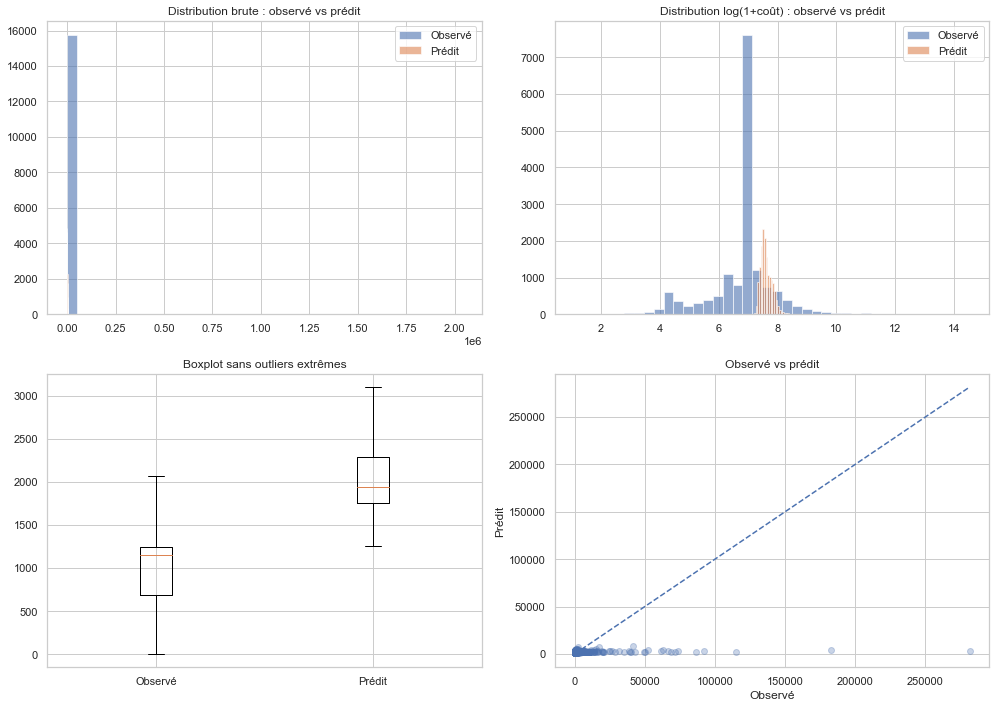

In [116]:

# 26. Graphiques observé vs prédit


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogrammes bruts
axes[0, 0].hist(severity_total["ClaimAmount_obs"], bins=40, alpha=0.6, label="Observé")
axes[0, 0].hist(severity_total["pred_claim_total"], bins=40, alpha=0.6, label="Prédit")
axes[0, 0].set_title("Distribution brute : observé vs prédit")
axes[0, 0].legend()

# Histogrammes log
axes[0, 1].hist(np.log1p(severity_total["ClaimAmount_obs"]), bins=40, alpha=0.6, label="Observé")
axes[0, 1].hist(np.log1p(severity_total["pred_claim_total"]), bins=40, alpha=0.6, label="Prédit")
axes[0, 1].set_title("Distribution log(1+coût) : observé vs prédit")
axes[0, 1].legend()

# Boxplot
axes[1, 0].boxplot([
    severity_total["ClaimAmount_obs"].values,
    severity_total["pred_claim_total"].values
], labels=["Observé", "Prédit"], showfliers=False)
axes[1, 0].set_title("Boxplot sans outliers extrêmes")

# Scatter observé vs prédit
sample_plot = severity_total.sample(min(3000, len(severity_total)), random_state=RANDOM_STATE)
axes[1, 1].scatter(
    sample_plot["ClaimAmount_obs"],
    sample_plot["pred_claim_total"],
    alpha=0.3
)
m = max(sample_plot["ClaimAmount_obs"].max(), sample_plot["pred_claim_total"].max())
axes[1, 1].plot([0, m], [0, m], linestyle="--")
axes[1, 1].set_title("Observé vs prédit")
axes[1, 1].set_xlabel("Observé")
axes[1, 1].set_ylabel("Prédit")

plt.tight_layout()
plt.show()

Résumé des erreurs :


,error,abs_error,ape
count,1.581800e+04,1.581800e+04,15818.000000
mean,-6.615373e+01,1.968165e+03,4.494116
std,2.114467e+04,2.105297e+04,22.259372
min,-2.024474e+06,4.745361e-01,0.000248
50%,8.447975e+02,9.994357e+02,0.761015
75%,1.409061e+03,1.546407e+03,1.914337
90%,1.801092e+03,2.094227e+03,9.225785
95%,2.106035e+03,2.701207e+03,22.226701
99%,2.674775e+03,1.351409e+04,45.770620
max,5.550007e+03,2.024474e+06,1246.521084


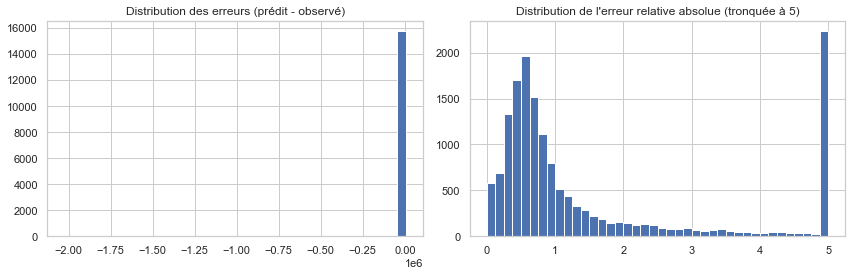

In [117]:

# 27. Analyse des erreurs


severity_total["error"] = severity_total["pred_claim_total"] - severity_total["ClaimAmount_obs"]
severity_total["abs_error"] = np.abs(severity_total["error"])
severity_total["ape"] = severity_total["abs_error"] / np.maximum(severity_total["ClaimAmount_obs"], 1)

print("Résumé des erreurs :")
display(
    severity_total[["error", "abs_error", "ape"]].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(severity_total["error"], bins=40)
axes[0].set_title("Distribution des erreurs (prédit - observé)")

axes[1].hist(np.clip(severity_total["ape"], 0, 5), bins=40)
axes[1].set_title("Distribution de l'erreur relative absolue (tronquée à 5)")

plt.tight_layout()
plt.show()

In [118]:

# 28. Comparaison observé vs prédit par segment


segment_vars = [c for c in ["DriverAge_cls", "CarAge_cls", "Density_cls", "Power_cls", "Brand_cls", "Region_cls", "Gas"] if c in severity_total.columns]

for var in segment_vars:
    print("\n" + "="*80)
    print(f"Comparaison par {var}")

    tab = (
        severity_total
        .groupby(var)
        .agg(
            n_obs=("ClaimAmount_obs", "size"),
            mean_obs=("ClaimAmount_obs", "mean"),
            mean_pred=("pred_claim_total", "mean"),
            median_obs=("ClaimAmount_obs", "median"),
            median_pred=("pred_claim_total", "median")
        )
        .reset_index()
    )
    tab["rel_gap_mean"] = (tab["mean_pred"] - tab["mean_obs"]) / tab["mean_obs"]
    display(tab.sort_values("mean_obs", ascending=False))


Comparaison par DriverAge_cls


,DriverAge_cls,n_obs,mean_obs,mean_pred,median_obs,median_pred,rel_gap_mean
4,Jeunes conducteurs [16-30],3090,3204.161489,2174.561399,1153.0,2057.378076,-0.321332
2,Conducteurs seniors ]60-80],2170,2179.654839,2096.259685,1165.0,1926.801229,-0.038261
0,Conducteurs expérimentés ]30-40],3449,1923.411714,2030.283818,1150.0,1913.797765,0.055564
1,Conducteurs mûrs ]40-50],4048,1761.340415,2030.845330,1154.0,1912.953490,0.153011
3,Conducteurs seniors actifs ]50-60],3061,1753.628226,2033.423807,1158.0,1919.300592,0.159552



Comparaison par CarAge_cls


,CarAge_cls,n_obs,mean_obs,mean_pred,median_obs,median_pred,rel_gap_mean
3,Véhicule âgé ]10-15],3573,2781.011195,1910.323539,1153.0,1848.789351,-0.313083
2,Véhicule récent [0-5],6301,2004.927631,2163.088207,1160.0,2012.624121,0.078886
1,Véhicule intermédiaire ]5-10],4946,1905.161140,2061.001842,1151.0,1886.987272,0.081799
0,Véhicule ancien ]15-20],998,1773.336673,2071.121629,1165.5,1931.406945,0.167924



Comparaison par Density_cls


...

,Brand_cls,n_obs,mean_obs,mean_pred,median_obs,median_pred,rel_gap_mean
2,French_core,8698,2318.286618,2025.795907,1150.0,1885.958095,-0.126167
3,Germanic_mainstream,1442,2199.009015,2078.398395,1151.0,1939.651990,-0.054848
4,Other,404,2128.844059,2070.697641,1163.0,1919.938019,-0.027314
5,Premium_DE_US,796,1955.129397,2160.505898,1157.5,1993.314090,0.105045
0,Asia,2062,1954.042192,2270.531088,1190.0,2157.712828,0.161966
6,US_Euro_mass,1709,1701.169105,2014.458225,1148.0,1876.343175,0.184161
1,Fiat,707,1519.125884,2005.102207,1144.0,1884.544822,0.319905



Comparaison par Region_cls


,Region_cls,n_obs,mean_obs,mean_pred,median_obs,median_pred,rel_gap_mean
0,C-B,8138,2513.709511,2037.528403,1152.0,1890.341434,-0.189434
1,IDF,2552,1769.259013,2127.794533,1171.0,2043.703785,0.202647
2,PC-NPDC-AQUIT,2734,1749.050841,2146.911346,1162.5,2010.141196,0.227472
3,PDL-BN-HN-LIM,2394,1674.476608,2019.509558,1146.0,1883.692375,0.206054



Comparaison par Gas


,Gas,n_obs,mean_obs,mean_pred,median_obs,median_pred,rel_gap_mean
1,Regular,7486,2350.205851,2056.896778,1154.0,1935.079835,-0.124801
0,Diesel,8332,1940.551848,2078.488960,1158.0,1935.451449,0.071081


In [119]:

# 29. Assuré de référence


reference_profile_manual = pd.DataFrame([{
    "DriverAge_cls": "Conducteurs expérimentés ]30-40]",
    "CarAge_cls": "Véhicule intermédiaire ]5-10]",
    "Density_cls": "Zone peu dense ]1-4]",
    "Power_cls": "f-g-h",
    "Brand_cls": "French_core",
    "Region_cls": "C-B",
    "Gas": "Diesel"
}])

display(reference_profile_manual)

,DriverAge_cls,CarAge_cls,Density_cls,Power_cls,Brand_cls,Region_cls,Gas
0,Conducteurs expérimentés ]30-40],Véhicule intermédiaire ]5-10],Zone peu dense ]1-4],f-g-h,French_core,C-B,Diesel


In [120]:
#30 Coût moyen assuré de reference

# TARIFICATION "CLASSES ONLY"
# - réentraîne les modèles uniquement sur les variables classées
# - calcule le coût total prédit pour un assuré de référence


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBRegressor
from scipy.stats import genpareto
import numpy as np
import pandas as pd

u = 6500 #seuil


# 1. Variables tarifaires en classes seulement

FEATURES_CLASS = [
    "DriverAge_cls",
    "CarAge_cls",
    "Density_cls",
    "Power_cls",
    "Brand_cls",
    "Region_cls",
    "Gas"
]

# on garde seulement celles qui existent vraiment
FEATURES_CLASS = [c for c in FEATURES_CLASS if c in claims_all.columns]


# 2. Préprocesseur classes only

class_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

prep_class = ColumnTransformer([
    ("cat", class_pipe, FEATURES_CLASS)
])


# 3. Fonction utilitaire : prédiction atypique log-excès

def predict_with_smearing_log_excess_model(fitted_model, X_train, y_train, X_test, u=6500):
    excess_train = np.asarray(y_train) - u
    excess_train = np.clip(excess_train, 0, None)

    log_pred_train = fitted_model.predict(X_train)
    smear = np.mean((1 + excess_train) / np.exp(log_pred_train))

    pred_excess = smear * np.exp(fitted_model.predict(X_test)) - 1
    pred_excess = np.clip(pred_excess, 0, None)

    pred_total = u + pred_excess
    return np.clip(pred_total, u, None)

def gpd_quantile(alpha, xi, beta, u):
    alpha = np.clip(alpha, 1e-8, 1 - 1e-8)
    if abs(xi) < 1e-8:
        exc_q = -beta * np.log(1 - alpha)
    else:
        exc_q = beta / xi * ((1 - alpha) ** (-xi) - 1)
    return u + exc_q


# 4. Modèle proba atypique - classes
final_prob_atyp_class_model = Pipeline([
    ("prep", prep_class),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

X_cls_full = claims_all[FEATURES_CLASS].copy()
y_cls_full = claims_all["is_atyp"].copy()

final_prob_atyp_class_model.fit(X_cls_full, y_cls_full)


# 5. Modèle attritionnel - classes

X_attr_class = attr_model[FEATURES_CLASS].copy()
y_attr_class = attr_model["ClaimAmount"].copy()

final_attr_class_model = Pipeline([
    ("prep", prep_class),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_attr_class_model.fit(X_attr_class, y_attr_class)


# 6. Modèle atypique XGB log-excès - classes

X_atyp_class = atyp_model[FEATURES_CLASS].copy()
y_atyp_class = atyp_model["ClaimAmount"].copy()

xgb_atyp_class_model = Pipeline([
    ("prep", prep_class),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=1.5,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_atyp_class_model.fit(
    X_atyp_class,
    np.log1p(np.clip(y_atyp_class - u, 0, None))
)


# 7. Q95 EVT sur toute la base atypique

full_excess = np.clip(np.asarray(y_atyp_class) - u, 0, None)
xi_full, loc_full, beta_full = genpareto.fit(full_excess, floc=0)
q95_evt_full = gpd_quantile(0.95, xi_full, beta_full, u)

# si best_alpha n'existe pas, on met 0.9 par défaut
alpha_hybrid = best_alpha if "best_alpha" in globals() else 0.9


# 8. ASSURÉ DE RÉFÉRENCE - classes

reference_profile_classes = pd.DataFrame([{
    "DriverAge_cls": "Conducteurs expérimentés ]30-40]",
    "CarAge_cls": "Véhicule intermédiaire ]5-10]",
    "Density_cls": "Zone peu dense ]1-4]",
    "Power_cls": "d-e",
    "Brand_cls": "French_core",
    "Region_cls": "C-B",
    "Gas": "Diesel"
}])

# garder seulement les colonnes effectivement utilisées
reference_profile_classes = reference_profile_classes[FEATURES_CLASS].copy()


# 9. Prédictions pour l'assuré de référence

ref_df = reference_profile_classes.copy()

# proba atypique
ref_df["pred_proba_atypique"] = final_prob_atyp_class_model.predict_proba(ref_df[FEATURES_CLASS])[:, 1]
ref_df["pred_proba_attritionnel"] = 1 - ref_df["pred_proba_atypique"]

# coût attritionnel
ref_df["pred_claim_attritionnel"] = np.clip(
    final_attr_class_model.predict(ref_df[FEATURES_CLASS]),
    0,
    None
)

# coût atypique XGB
pred_xgb_atyp_ref = predict_with_smearing_log_excess_model(
    xgb_atyp_class_model,
    X_atyp_class,
    y_atyp_class,
    ref_df[FEATURES_CLASS],
    u=u
)
ref_df["pred_xgb_atypique"] = pred_xgb_atyp_ref

# coût atypique hybride
ref_df["pred_hybride_atypique"] = (
    alpha_hybrid * ref_df["pred_xgb_atypique"]
    + (1 - alpha_hybrid) * q95_evt_full
)

# coût total attendu
ref_df["pred_claim_total"] = (
    (1 - ref_df["pred_proba_atypique"]) * ref_df["pred_claim_attritionnel"]
    + ref_df["pred_proba_atypique"] * ref_df["pred_hybride_atypique"]
)

display(ref_df.T.rename(columns={0: "Valeur"}))

,Valeur
DriverAge_cls,Conducteurs expérimentés ]30-40]
CarAge_cls,Véhicule intermédiaire ]5-10]
Density_cls,Zone peu dense ]1-4]
Power_cls,d-e
Brand_cls,French_core
Region_cls,C-B
Gas,Diesel
pred_proba_atypique,0.029139
pred_proba_attritionnel,0.970861
pred_claim_attritionnel,1168.471436


On obtient une prime qui est presuqe le double de clele obtenue par un raisonnement GLM( si on considère la frequence obtenue par GLM) , ce qui est abhérent et s'explique par le fait que les sinistres atypiques sont ajoutés sous forme de surcharges à la prime attritionnelle obtneue dans la méthode avec les GLMalors que dans la methode ici , il sont directement incorporée au tarif sous forme d'une prime de creidbilité en utilisant la probabilité que le coût des sinistres contienne un sinistre atypique ou pas 

# Conclusion générale sur la modélisation des coûts

## Synthèse de la méthodologie mise en œuvre

La démarche suivie a consisté à décomposer la composante coût du tarif automobile en deux sous-populations de sinistres : les **sinistres attritionnels**, fréquents et de montant modéré, et les **sinistres atypiques**, rares mais potentiellement très élevés. Cette séparation était nécessaire car l’analyse descriptive a montré que les deux populations ne suivent pas la même logique statistique : les attritionnels restent relativement modélisables, tandis que les atypiques présentent une queue extrêmement lourde, une forte asymétrie et une grande instabilité.

Dans un premier temps, un important travail de **segmentation** et de **regroupement des modalités** a été réalisé, afin de construire des classes plus homogènes et plus interprétables pour les variables tarifaires principales. Cette étape était indispensable pour disposer de bases cohérentes et exploitables, à la fois par des modèles classiques et par des modèles plus flexibles.

Ensuite, la modélisation des **coûts attritionnels** a été testée à l’aide de plusieurs approches de machine learning : Random Forest, HistGradientBoosting, Gradient Boosting, XGBoost et LightGBM. Les résultats ont montré que, malgré cette diversification des méthodes, les performances restaient très proches d’une simple baseline fondée sur la moyenne globale. Le meilleur modèle de machine learning, **XGBoost sur coût brut**, atteint un niveau très voisin de la moyenne, ce qui suggère que les variables disponibles apportent peu d’information prédictive supplémentaire sur la sévérité attritionnelle.

La modélisation des **coûts atypiques** a conduit à une conclusion différente. L’analyse de la queue a confirmé la pertinence d’un cadre EVT/GPD pour caractériser les excès au-dessus du seuil retenu, mais l’utilisation directe de l’espérance issue de la GPD s’est révélée trop instable. En parallèle, plusieurs modèles de machine learning ont été testés sur le logarithme de l’excès au-dessus du seuil, et **XGBoost sur log-excès** est apparu comme le meilleur outil de prédiction individuelle. Une approche hybride, combinant la prédiction XGBoost et un ancrage EVT via le quantile 95 %, a ensuite été retenue comme compromis entre performance prédictive et prudence actuarielle.

Enfin, une modélisation de la **probabilité d’être atypique** a été menée à l’aide de plusieurs classifieurs. Le modèle retenu, **HistGradientBoostingClassifier**, a montré une calibration satisfaisante et une capacité raisonnable à discriminer les profils à risque atypique.

---

## Avantages de l’approche retenue

Cette méthodologie présente plusieurs intérêts.

D’abord, elle permet de **traiter séparément des phénomènes de nature très différente**, ce qui est plus réaliste que d’essayer de modéliser tous les sinistres dans un cadre unique. La séparation attritionnel / atypique rend l’analyse plus robuste et plus cohérente avec la pratique actuarielle.

Ensuite, l’utilisation de plusieurs niveaux de modèles a permis d’identifier les situations dans lesquelles les méthodes avancées sont réellement utiles. En particulier, les modèles de boosting ont montré un intérêt sur les sinistres atypiques, alors que sur les attritionnels, leur gain par rapport à des approches plus simples est resté très limité.

De plus, la démarche a permis de mettre en évidence qu’un modèle de machine learning peut être utile non pas nécessairement comme modèle unique final, mais comme **outil complémentaire** à une logique actuarielle plus prudente. C’est particulièrement vrai pour la composante atypique, où la combinaison d’un modèle prédictif et d’un ancrage EVT permet de mieux équilibrer performance statistique et cohérence métier.

---

## Limites et inconvénients de l’approche

Malgré son intérêt, cette méthodologie présente aussi plusieurs limites importantes.

La première limite est liée à la **superposition de plusieurs couches de modélisation** : segmentation des variables, séparation des sinistres, modélisation de la sévérité attritionnelle, modélisation des atypiques, estimation de la probabilité d’être atypique, puis combinaison finale. Chaque étape apporte potentiellement sa propre erreur d’estimation. Au final, le coût total estimé résulte d’un empilement de modèles, ce qui accroît le risque d’instabilité et rend l’interprétation plus délicate.

La deuxième limite concerne la **prise en compte des sinistres atypiques**. Si l’on intègre directement leur coût attendu dans la formule finale via une expression du type  
\[
(1-p_{atyp}) \times C_{attr} + p_{atyp} \times C_{atyp},
\]
on obtient souvent des coûts moyens très élevés. Cela s’explique par la combinaison d’une probabilité atypique faible mais non nulle avec un coût atypique conditionnel très important. En pratique, cela peut conduire à un tarif trop chargé et donc **peu compétitif** par rapport à des approches plus prudentes.

La troisième limite est celle de l’**interprétabilité**. Plus les modèles sont sophistiqués, plus il devient difficile d’expliquer précisément d’où vient le tarif. Or, en assurance, la lisibilité du tarif et la capacité à le justifier sont des enjeux majeurs. De ce point de vue, les **GLM** conservent un avantage important : ils sont plus simples, plus lisibles, plus faciles à expliquer, et souvent plus acceptables dans un cadre opérationnel ou concurrentiel.

---

## Conclusion méthodologique sur la prise en compte des atypiques

L’un des enseignements majeurs de ce travail est que la composante atypique ne doit probablement **pas être intégrée directement** dans le coût moyen final comme une espérance pleine. En effet, une telle intégration conduit à des niveaux de coût trop élevés et peu cohérents avec un usage tarifaire réaliste.

Deux solutions apparaissent plus pertinentes :

### 1. Garder les atypiques sous forme de surcharge séparée
C’est l’option la plus proche de la logique GLM observée dans le projet. On retient une composante attritionnelle prédite, puis on ajoute une **surprime atypique** ou un chargement spécifique, calibré de manière prudente. Cette approche est plus simple, plus stable et plus cohérente avec la pratique.

### 2. Introduire un facteur de crédibilité
Une autre solution consiste à retenir une formule du type  
\[
C_{final} = C_{attr} + \lambda \times p_{atyp} \times C_{atyp},
\]
avec un facteur de crédibilité \( \lambda \in [0,1] \). Cela permet de conserver l’information issue du machine learning sur les atypiques, sans pour autant la faire peser intégralement sur le tarif. Cette piste est particulièrement intéressante, car elle traduit bien le fait que la composante atypique reste trop incertaine pour être utilisée à pleine intensité.

En conséquence, **la recommandation finale** est de retenir, pour la partie coût, une approche où :
- la **sévérité attritionnelle** constitue la base principale du coût ;
- la composante atypique est conservée comme **surcharge** ou **composante crédibilisée** ;
- l’intégration directe complète du coût atypique est évitée, car elle risquerait de rendre le tarif final peu compétitif.

---

## Pistes d’amélioration

Plusieurs pistes pourraient améliorer sensiblement la qualité de la modélisation des coûts.

La première, et sans doute la plus importante, est l’**enrichissement des données**. Le principal frein à l’utilisation efficace de méthodes avancées vient du manque d’information réellement explicative dans les bases disponibles. En l’absence de variables plus riches, même des modèles puissants comme XGBoost ou LightGBM ne peuvent exploiter qu’une information limitée.

Parmi les variables qui auraient été particulièrement utiles pour mieux modéliser les coûts, on peut citer :
- **le CRM / bonus-malus**, qui résume une partie de l’historique de sinistralité et du comportement de conduite ;
- **le kilométrage annuel parcouru**, qui reflète beaucoup mieux l’exposition réelle au risque que la simple durée d’assurance ;
- **l’usage du véhicule** ou, à défaut, une variable d’usage plus fine (privé, domicile-travail, professionnel), car le coût et la fréquence des sinistres dépendent fortement du contexte d’utilisation.

On pourrait aussi mentionner, selon les disponibilités possibles, l’**ancienneté du permis**, la **valeur du véhicule**, ou encore des variables directement liées au sinistre (type de dommage, responsabilité, coût de réparation, type de garantie mobilisée), qui auraient probablement beaucoup amélioré la modélisation de la sévérité.

La seconde piste d’amélioration consiste à mieux distinguer l’objectif **prédictif individuel** et l’objectif **tarifaire**. Un bon modèle de prédiction dossier par dossier n’est pas nécessairement le meilleur modèle pour construire un tarif stable et compétitif. Une logique hybride, combinant modèles prédictifs et chargements actuariels calibrés, semble ici plus adaptée.

Enfin, une fois la **fréquence** obtenue séparément, la construction du tarif final devra être faite avec prudence. Il ne suffira pas de multiplier mécaniquement fréquence et coût si la composante atypique reste trop incertaine. Une calibration finale du tarif, éventuellement avec des contraintes de cohérence, de compétitivité et d’interprétabilité, sera nécessaire.

---

## Conclusion finale

En définitive, ce travail montre que les méthodes avancées de machine learning apportent une réelle valeur ajoutée pour explorer la structure des coûts, tester plusieurs scénarios et mieux comprendre la composante atypique. Elles permettent de mettre en évidence des effets et des comportements que les modèles plus simples ne captent pas toujours directement.

Cependant, compte tenu de la qualité et de la richesse limitées des données, ces méthodes ne peuvent pas être exploitées à pleine puissance. Dans ce contexte, les approches les plus sophistiquées ne remplacent pas totalement les modèles plus simples ; elles les complètent. La solution la plus pertinente semble donc être une approche **hybride et prudente**, dans laquelle :
- les **GLM** ou des approches proches restent une référence forte pour la lisibilité et la stabilité ;
- les modèles de **machine learning** servent à affiner la compréhension du risque, notamment atypique ;
- la composante atypique est intégrée avec précaution, sous forme de **surcharge** ou de **composante crédibilisée**, plutôt que comme une espérance brute complète.

Cette conclusion est cohérente à la fois avec les résultats empiriques obtenus, avec les contraintes du marché concurrentiel de l’assurance automobile, et avec les limites d’information des bases utilisées.
